# Requirements

In case an NVIDIA GPU is available on your machine, we recommend to install CUDA additional requirement. This greatly accelerates the machine-learning-based evaluation in this section. **Do not execute this, if you do not have such a GPU!**

```sh
pip install --upgrade --extra-index-url=https://pypi.nvidia.com "cuml-cu12==25.6.*"
```

You also might need to [expose the GPU to the docker compose container](https://docs.docker.com/engine/containers/gpu/). Since we used a Slurm-based cluster for the steps using CUDA, we were not able to test this.

In [1]:
import copy
import itertools
import os
import pathlib
import re

from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot
import numpy
import pandas
import polars
import seaborn
from tqdm.notebook import tqdm

from utils import list_code
from list_scenarios import (
    list_scenarios,
    list_scenarios_full,
    PROTOCOLS,
    LINK_LAYERS,
    LINK_LAYER_MODES,
    BLOCKWISE,
    NETWORK_SETUPS ,
    DATA_FORMATS,
    DNS_FORMATS,
    RANDIV_PAD,
)

EVALUATION_PATH = pathlib.Path.cwd()
ML_ID_DNS_PATH = EVALUATION_PATH / "05_ml_to_identify_dns_traffic"
INPUT_PATH = EVALUATION_PATH / "output_dataset"

os.environ["EVALUATION_PATH"] = str(EVALUATION_PATH)
os.environ["ML_ID_DNS_PATH"] = str(ML_ID_DNS_PATH)
os.environ["INPUT_PATH"] = str(INPUT_PATH)

FEATURE_VECTORS = ["binvec", #"word2vec"
                  ]

FEATURE_VECTOR_READABLE = {
    "binvec": "Binary Vector",
    "word2vec": "Word2Vec",
}

PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore_base": "OSCORE",
    "oscore": "Onion\nOSCORE",
}
LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
LINK_LAYER_MODE_READABLE = {
    "": "",
    "-min-rules": "min_rules",
    "-peer-based": "peer_based",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b64": "64",
}
DNS_FORMAT_READABLE = {
    "dns_message": "application/dns-message",
    "dns_cbor": "application/dns+cbor",
}

# Preparations

## Generate Feature Vectors

In [2]:
list_code(ML_ID_DNS_PATH / "binvec.sh")

#! /bin/bash
#
# binvec.sh
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR=$( cd -- "$( dirname -- "$(realpath "$0")" )" &> /dev/null && pwd )
PROCS=$(grep -c '^processor' /proc/cpuinfo)
if [ $PROCS -gt 16 ]; then
    # Every process needs a lot of memory
    PROCS=16
fi
INPUT_PATH="${INPUT_PATH:-${SCRIPT_DIR}/output_dataset}"

binvec() {
    export POLARS_FORCE_NEW_STREAMING=1
    export INPUT_PATH
    ${SCRIPT_DIR}/binvec.py "$1"
}

export -f binvec
export INPUT_PATH
export SCRIPT_DIR
echo "Running on ${PROCS} workers"
${SCRIPT_DIR}/../list_scenarios.py $* | parallel -j "${PROCS}" binvec

In [3]:
list_code(ML_ID_DNS_PATH / "binvec.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import concurrent.futures
import multiprocessing
import os
import pathlib
import sys
import traceback
import warnings

import polars
import numpy


EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = pathlib.Path(
    os.environ.get("INPUT_PATH", EVALUATION_DIR / "output_dataset")
)


def scenario2vec(scenario):
    file = INPUT_PATH / f"{scenario}.training.csv.gz" 
    vector_file = INPUT_PATH / f"{scenario}.binvec.parquet"

    if not file.exists():
        print(f"Skipping {file} since it does not exist")
        return
    elif vector_file.exists():
        print(f"Skipping {file} since {vector_file} exists")
        return
    print("Processing", str(file))

    df = polars.scan_csv(file, separator=";").with_columns(
        polars.col("eth.payload").map_elements(
            lambda hex_msg: numpy.concatenate(
                [
                    # convert hex nibbles to bits
                    [int(b) for b in bin(int(x, base=16))[2:].zfill(4)]
                    # Padding is marked with "x", use 2 for padding in binary space
                    if x != "x" else ([2] * 4)
                    for x in hex_msg
                ]
            ).tolist(),
            return_dtype=polars.List(polars.Int8),
        ),
        (polars.col("client.type") == "dns").cast(
            polars.Int8
        )
    ).select(
        polars.col("eth.payload"),
        polars.col("client.type"),
    ).rename(
        {"eth.payload": "vector", "client.type": "label"}
    ).sink_parquet(vector_file, compression="lz4")
    del df
    print("Created", str(vector_file))


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "scenario",
        help="Name of the scenario to train for",
    )
    args = parser.parse_args()

    scenario2vec(args.scenario)


if __name__ == "__main__":
    main()

To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${ML_ID_DNS_PATH}'/../.env/bin/activate;` before the `INPUT_PATH='${INPUT_PATH}' hyperfine ...`). We use the [`hyperfine` benchmarking tool](https://github.com/sharkdp/hyperfine) to provide an estimate on how long `binvec.sh` runs. You can find the resulting output (including the estimated time) in [`output_dataset/binvec.log`](./output_dataset/binvec.log).

In [4]:
%%bash

tmux new-session -s "binvec" -d script -efq "${INPUT_PATH}/binvec.log" -c "INPUT_PATH='${INPUT_PATH}' hyperfine --warmup 0 --max-runs 1 --show-output --ignore-failure '${ML_ID_DNS_PATH}/binvec.sh'"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "binvec"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "binvec" C-c
```

## Alternative Feature Vectors

We also used the natural language processing technique [Word2vec](https://en.wikipedia.org/wiki/Word2vec) to generate a feature vector. Since that vector is however larger and we can train the models with the binary vector approach above sufficiently, we did not use its results in our final evaluation. Due to there size, even cluster nodes easily came to their ends of resource allocation and the training took overall longer. If you want to look into those, just take the commands above and replace `binvec` with `word2vec`. We also included them in our results below for 1 run of the ML models. Missing results are due to failure, either due to resource exhaustion or because preconditions were not met: sometimes the Word2vec vector contained negative numbers, however, e.g., Naïve Bayes expects only positive numbers in the input vector.

# $k$-Fold Cross Validation

For our evaluation we picked $k = 5$. First, we check if preparations went through successfully.

In [ ]:
display(Markdown("## Checking for missing vector files"))
missing = 0
for vector in FEATURE_VECTORS:
    display(Markdown(f"### {FEATURE_VECTOR_READABLE[vector]}"))
    for scenario in list_scenarios():
        vector_file = INPUT_PATH / f"{scenario}.{vector}.parquet"
        training_file = INPUT_PATH / f"{scenario}.training.csv.gz"
        if not vector_file.exists():
            display(Markdown(f"#### ❌ {scenario}: Vector file does not exist\n"
                             f"If you run the training TMUX without it, scenario {scenario} **will not be evaluated**!"))
            missing += 1
            if not training_file.exists():
                display(Markdown("\nBut training file does not exist either..."))
            continue
        if not training_file.exists():
            display(Markdown("Training file does not exist to check completeness"))
            continue
        training_df = polars.read_csv(training_file, separator=";", columns=["client.type"])
        try:
            vector_df = polars.read_parquet(vector_file, columns=["label"])
        except Exception as exc:
            display(
                Markdown(
                    f"#### ❌ {scenario}: Broken vector file\n"
                    f"{exc}"
                )
            )
            missing += 1
            del training_df
            continue
        if vector_df.shape != training_df.shape:
            display(
                Markdown(
                    f"#### ❌ {scenario}: Vector file has wrong size. "
                    f"Expected: {training_df.shape}, Actual: {vector_df.shape}"
                )
            )
            missing += 1
        del training_df
        del vector_df
if missing == 0:
    display("All vector files are complete")

## Running the Cross Validation in TMUX

We only ran a few runs with this method and later changed to a slurm-based cluster (see below). We still used the [cross_validate.py](./05_ml_to_identify_dns_traffic/cross_validate.py) script for that.

In [6]:
list_code(ML_ID_DNS_PATH / "cross_validate.sh")

#! /bin/bash
#
# training.sh
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR=$( cd -- "$( dirname -- "$(realpath "$0")" )" &> /dev/null && pwd )
INPUT_PATH="${INPUT_PATH:-${SCRIPT_DIR}/../output_dataset}"
CLASSIFIERS=(
    "lr"
    "knn"
    # Our datasets have >4.7 billion (> 2 * 120699 * 1219 * 16) samples for which SVM
    # does not scale (not recommended for >1 million, 10-100k samples are best, see
    # https://github.com/scikit-learn/scikit-learn/issues/18027#issuecomment-800873636
    # ). For our particular datasets it crashes due to Int32 overflow error.
    # We keep the code for smaller samples and CUDA though.
    "svm"
    "dt"
    "rf"
    "ab"
)

vec="binvec"
args=""

while getopts ":c:D:d:l:n:p:r:v:" opt; do
    case "${opt}" in
    c)  classifier="${OPTARG}";;
    p)  prots="${prots}_${OPTARG}"; args="${args} -p ${OPTARG}";;
    D)  data="${data}_${OPTARG}"; args="${args} -D ${OPTARG}";;
    d)  dns="${dns}_${OPTARG}"; args="${args} -d ${OPTARG}";;
    l)  link_layer="${link_layer}_${OPTARG}"; args="${args} -l ${OPTARG}";;
    n)  network_setups="${network_setups}_${OPTARG}"; args="${args} -n ${OPTARG}";;
    v)  vec="${OPTARG}";;
    *)  prots="${prots}_${OPTARG}"; args="${args} -p ${OPTARG}";;
    esac
done

"${SCRIPT_DIR}"/list_scenarios.py $args | while read scenario; do
    for cls in "${CLASSIFIERS[@]}"; do
        if [[ -n "${classifier}" && "$cls" != "${classifier}" ]]; then
            continue
        fi
        "${SCRIPT_DIR}"/cross_validate.py -v "${vec}" "${scenario}" "${cls}"
        RESULT="$?"
        if [[ "${RESULT}" -eq 128 || "${RESULT}" -eq 2 ]]; then
            # error code indicates that all classifiers where already evaluated or arguments were
            # wrong, take next scenario
            break
        fi
    done
    if [[ "${RESULT}" -eq 2 ]]; then
        break
    fi
done &> "${INPUT_PATH}/cross_validation_${classifier}_${step}${prots}${network_setups}${link_layer}${data}${dns}_${vec}_${SLURM_JOB_ID}.log"

In [7]:
list_code(ML_ID_DNS_PATH / "cross_validate.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import csv
import os
import pathlib
import psutil
import sys
import time
import traceback
import warnings

import numpy
import polars
import polars.exceptions

from list_scenarios import (
    parse_scenario_name,
)


EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = pathlib.Path(
    os.environ.get("INPUT_PATH", EVALUATION_DIR / ".." / "output_dataset")
)

K = 5
SCORINGS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc",
]

CLASSIFIERS = [
    "lr",
    "knn",
    "svm",
    "dt",
    "rf",
    "ab",
]
FIELD_NAMES = [
    "protocol",
    "link_layer",
    "link_layer_mode",
    "blocksize",
    "network_setup",
    "data_format",
    "dns_format",
    "randiv_pad",
    "vector_type",
    "k",
    "classifier",
    "classifier_args",
    "job_id",
    "fit_time",
    "score_time",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "balanced_accuracy",
    "roc_auc",
]

LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
LINK_LAYER_MODE_READABLE = {
    "": "",
    "-min-rules": "min_rules",
    "-peer-based": "peer_based",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b64": "64",
}

CLASSIFIER_READABLE = {
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest (Ensemble Learning III)",
    "ab": "AdaBoost (SAMME)"
}
CLASSIFIER_ARGS = {
    "lr": {"max_iter": 2800},
    "knn": {
        "algorithm": "brute",
        "n_jobs": -1,
    },
    "svm": {"C": 0.01},
    "dt": {},
    "rf": {"n_estimators": 250, "max_depth": 9},
    "ab": {"n_estimators": 250},
}


def cross_validate(model, x, y):
    return sk_model_selection.cross_validate(
        model,
        x,
        y,
        cv=K,
        scoring=SCORINGS,
    )


def cross_validate_lr(x, y):
    lr = sk_linear_model.LogisticRegression(**CLASSIFIER_ARGS["lr"])
    try:
        return cross_validate(lr, x, y)
    finally:
        del lr


def cross_validate_knn(x, y):
    knn = sk_neighbors.KNeighborsClassifier(**CLASSIFIER_ARGS["knn"])
    try:
        return cross_validate(knn, x, y)
    finally:
        del knn


def cross_validate_svm(x, y):
    svm = sk_svm.LinearSVC(**CLASSIFIER_ARGS["svm"])
    try:
        return cross_validate(svm, x, y)
    finally:
        del svm


def cross_validate_dt(x, y):
    dt = sk_tree.DecisionTreeClassifier(**CLASSIFIER_ARGS["dt"])
    try:
        return cross_validate(dt, x, y)
    finally:
        del dt


def cross_validate_rf(x, y):
    rf = sk_ensemble.RandomForestClassifier(**CLASSIFIER_ARGS["rf"])
    try:
        return cross_validate(rf, x, y)
    finally:
        del rf


def cross_validate_ab(x, y):
    ab = AdaBoostClassifier(**CLASSIFIER_ARGS["ab"])
    try:
        return cross_validate(ab, x, y)
    finally:
        del ab


CROSS_VALIDATE = {
    "lr": cross_validate_lr,
    "knn": cross_validate_knn,
    "svm": cross_validate_svm,
    "dt": cross_validate_dt,
    "rf": cross_validate_rf,
    "ab": cross_validate_ab,
}


def process_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss


def str_classifier_args(classifier):
    args = ",".join(
        f"{k}={v}"
        for k, v
        in CLASSIFIER_ARGS[classifier].items()
        if k != "output_type"
    )
    if args:
        return args
    return None


def configure_cuml():
    sklearn = __import__("sklearn")
    globals()["AdaBoostClassifier"] = sklearn.ensemble.AdaBoostClassifier

    try:
        if int(os.environ.get("FORCE_SKLEARN", "0")):
            raise ImportError(f"FORCE_SKLEARN={os.environ['FORCE_SKLEARN']}")

        cuml = __import__("cuml")
        globals()["cuml"] = cuml
        globals()["sk_ensemble"] = cuml.ensemble
        globals()["sk_linear_model"] = cuml.linear_model


To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${ML_ID_DNS_PATH}'/../.env/bin/activate;` before the `INPUT_PATH='${INPUT_PATH}' '${EVALUATION_PATH}/cross_validate.sh'`).

In [ ]:
%%bash

tmux new-session -s "cross_validate" -d "INPUT_PATH='${INPUT_PATH}' '${EVALUATION_PATH}/cross_validate.sh'"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "cross_validate"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "cross_validate" C-c
```

## Alternative: Run on a slurm-based cluster

If you have access to a slurm-based cluster with GPUs, we also provided a batch script for that. For the non-GPU-based classifiers (AB and DT) it is usually faster to use `--array`-based tasks:

```sh
#SBATCH --account=<your project>
#SBATCH --array=0-<elements>
#SBATCH --output=cross_validation_array_%A_%a.out
#SBATCH --error=cross_validation_array_%A_%a.err
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=400000
#SBATCH --time=7-00:00:00

JOBS=$(SCRIPT_PATH)/../list_scenarios.py)  # use -r if you want to exclude _randiv_pad scenarios)
```

You can then execute the jobs in `${JOBS}` using the following command instead of the `srun` command:

```sh
"${VENV}"/bin/python "${SCRIPT_PATH}"/cross_validate.py -v "binvec" "${JOBS[${SLURM_ARRAY_TASK_ID}]}" "ab"
```

In [9]:
list_code(ML_ID_DNS_PATH / "cross_validate_slurm.sh")

#!/bin/bash
#
# cross_validate_slurm.sh
# Copyright (C) 2025-26 TU Dresden
#
# Distributed under terms of the MIT license.
#

#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=96:00:00

module purge
module load release/24.10 GCCcore/13.3.0 CUDA/12.6.0 Python/3.12.3

SCRIPT_PATH=${PWD}
export INPUT_PATH="${INPUT_PATH:-${SCRIPT_PATH}/../output_dataset}"
export VENV="${VENV:-"${INPUT_PATH}"/.env-cuml}"

if ! [ -f "${VENV}"/bin/activate ]; then
    python -m venv "${VENV}"
fi	

# You can comment this out if you already installed the requirements 
. "${VENV}"/bin/activate && \
  	pip install --upgrade uv &&
  	uv pip install --upgrade -r "${SCRIPT_PATH}"/../requirements.txt &&
  	pip install --upgrade --extra-index-url=https://pypi.nvidia.com "cuml-cu12==25.6.*"
# installing from pypi.nvidia.com does not work with uv...

srun "${PWD}"/cross_validate.sh -p coaps          -D "json" -v binvec : \
     "${PWD}"/cross_validate.sh -p coap -p https  -D "json" -v binvec : \
     "${PWD}"/cross_validate.sh -p oscore         -D "json" -v binvec : \
     "${PWD}"/cross_validate.sh -p oscore-base    -D "json" -v binvec : \
     "${PWD}"/cross_validate.sh -p coaps          -D "cbor" -v binvec : \
     "${PWD}"/cross_validate.sh -p coap -p https  -D "cbor" -v binvec : \
     "${PWD}"/cross_validate.sh -p oscore         -D "cbor" -v binvec : \
     "${PWD}"/cross_validate.sh -p oscore-base    -D "cbor" -v binvec
wait

You can execute it like this:

```sh
sbatch cross_validate_slurm.sh
```

### Merge Cross Validation Results

The `cross_validate.py` script slices by classifier. The following script merges all CSVs for a scenario to one CSV file.

In [10]:
CLASSIFIERS_ORDER = [
    "lr",
    "knn",
    "svm",
    "dt",
    "rf",
    "ab",
]
SCHEMA_OVERRIDES = {
    "blocksize": polars.Int16,
    "k": polars.Int8,
    "randiv_pad": polars.Int8,
    "job_id": polars.Int64,
    "repeats": polars.Int8,
    "feature": polars.Int16,
    "start": polars.Int32,
    "stop": polars.Int32,
    "accuracy_mean": polars.Float64,
    "accuracy_std": polars.Float64,
    "precision_mean": polars.Float64,
    "precision_std": polars.Float64,
    "recall_mean": polars.Float64,
    "recall_std": polars.Float64,
    "f1_mean": polars.Float64,
    "f1_std": polars.Float64,
    "balanced_accuracy_mean": polars.Float64,
    "balanced_accuracy_std": polars.Float64,
    "roc_auc_mean": polars.Float64,
    "roc_auc_std": polars.Float64,
}


for scenario in tqdm(list_scenarios(), total=len(list(list_scenarios()))):
    try:
        df = polars.concat(
            map(
                lambda file: polars.read_csv(
                    file,
                    separator=";",
                    schema_overrides=SCHEMA_OVERRIDES,
                ),
                list(INPUT_PATH.glob(f"{scenario}.cross_val.csv"))
                + list(INPUT_PATH.glob(f"{scenario}.*.cross_val.csv"))
            )
        )
    except ValueError:
        # File did not exist (yet)
        continue
    # Clean up some inconsistencies in our calculations
    if df.filter((polars.col("classifier") == "ab") & (polars.col("job_id") < 21000000)).is_empty():
        df = df.sort("job_id", descending=True)
    else:
        df = df.sort("job_id")
    df = df.unique(
        [
            "protocol",
            "link_layer",
            "link_layer_mode",
            "blocksize",
            "network_setup",
            "data_format",
            "dns_format",
            "randiv_pad",
            "vector_type",
            "k",
            "classifier",
            "classifier_args",
        ],
        keep="last",
    )

    columns = df.collect_schema().names()
    df = df.with_columns(
        cls_index=polars.col("classifier").map_elements(
            lambda c: CLASSIFIERS_ORDER.index(c),
            return_dtype=polars.Int8,
        )
    ).sort("cls_index").select(columns)
    output_path = INPUT_PATH / f"{scenario}.cross_val.csv"
    df.write_csv(output_path, separator=";")

    # our central storage automatically sets the exec bit, so set it prematurely
    # so we do not get any syncing issues.
    output_path.chmod(0o755)

  0%|          | 0/456 [00:00<?, ?it/s]

## Plot Results

### Summarize Models (Binary Vector)

Here we generate the plots for our model selection. **Base Scenarios** below shows the plots we included in Figure 9 of our paper.

#### All Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",456,"""5.0±0.0""",1.0,"""591.0±212.6""","""13.9±11.2""","""0.872±0.024""","""0.850±0.030""","""0.804±0.039""","""0.819±0.034"""
"""KNN""",456,"""5.0±0.0""",1.0,"""22.9±18.8""","""61.7±11.8""","""0.846±0.025""","""0.800±0.030""","""0.799±0.038""","""0.797±0.034"""
"""SVM""",456,"""4.5±1.0""",0.904386,"""269.7±285.9""","""8.4±8.0""","""0.868±0.026""","""0.846±0.032""","""0.798±0.043""","""0.813±0.037"""
"""DT""",456,"""5.0±0.0""",1.0,"""201.2±36.7""","""2.3±0.3""","""0.845±0.029""","""0.799±0.035""","""0.795±0.052""","""0.794±0.041"""
"""RF""",456,"""5.0±0.0""",1.0,"""525.4±323.5""","""23.8±29.2""","""0.859±0.025""","""0.850±0.026""","""0.776±0.048""","""0.797±0.040"""
"""AB""",456,"""5.0±0.0""",1.0,"""11038.2±1876.7""","""459.6±75.7""","""0.863±0.025""","""0.838±0.031""","""0.782±0.043""","""0.801±0.038"""


##### [Times](plots/classifier_times.pdf)

<Figure size 358.544x100.724 with 0 Axes>

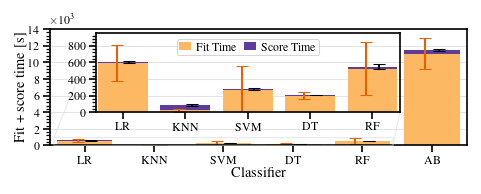

##### [Metrics](plots/classifier_metrics.pdf)

<Figure size 358.544x100.724 with 0 Axes>

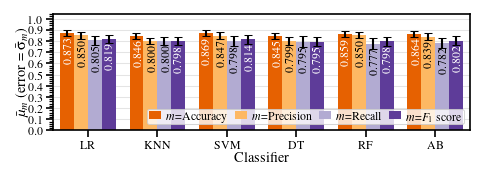

#### Base Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",296,"""5.0±0.0""",1.0,"""676.9±237.0""","""17.0±14.6""","""0.890±0.028""","""0.872±0.034""","""0.834±0.044""","""0.848±0.040"""
"""KNN""",296,"""5.0±0.0""",1.0,"""26.5±24.1""","""61.9±8.1""","""0.870±0.028""","""0.832±0.034""","""0.832±0.044""","""0.830±0.039"""
"""SVM""",296,"""4.5±1.0""",0.904054,"""366.6±405.6""","""10.8±11.0""","""0.885±0.031""","""0.868±0.035""","""0.826±0.050""","""0.842±0.043"""
"""DT""",296,"""5.0±0.0""",1.0,"""205.5±45.2""","""2.4±0.3""","""0.865±0.035""","""0.825±0.041""","""0.820±0.061""","""0.820±0.049"""
"""RF""",296,"""5.0±0.0""",1.0,"""587.5±338.0""","""31.7±39.7""","""0.879±0.030""","""0.870±0.030""","""0.814±0.057""","""0.834±0.047"""
"""AB""",296,"""5.0±0.0""",1.0,"""11371.4±1988.2""","""469.5±76.5""","""0.880±0.029""","""0.864±0.036""","""0.813±0.046""","""0.831±0.042"""


##### [Times](plots/classifier_times_base.pdf)

<Figure size 358.544x100.724 with 0 Axes>

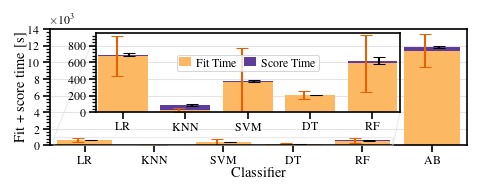

##### [Metrics](plots/classifier_metrics_base.pdf)

<Figure size 358.544x100.724 with 0 Axes>

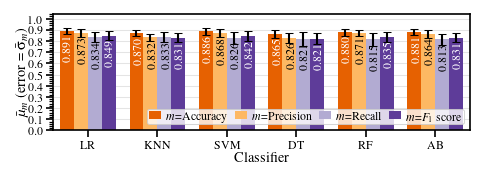

#### Random IV/Padding Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",160,"""5.0±0.0""",1.0,"""432.1±167.5""","""8.0±4.9""","""0.839±0.017""","""0.808±0.024""","""0.750±0.030""","""0.765±0.024"""
"""KNN""",160,"""5.0±0.0""",1.0,"""16.3±8.9""","""61.4±18.7""","""0.802±0.018""","""0.740±0.022""","""0.738±0.028""","""0.736±0.024"""
"""SVM""",160,"""4.5±1.0""",0.905,"""90.5±64.5""","""4.0±2.3""","""0.836±0.018""","""0.806±0.025""","""0.746±0.030""","""0.761±0.025"""
"""DT""",160,"""5.0±0.0""",1.0,"""193.3±21.0""","""2.1±0.4""","""0.808±0.018""","""0.749±0.024""","""0.747±0.036""","""0.747±0.026"""
"""RF""",160,"""5.0±0.0""",1.0,"""410.7±296.6""","""9.1±9.8""","""0.820±0.016""","""0.811±0.020""","""0.706±0.031""","""0.729±0.026"""
"""AB""",160,"""5.0±0.0""",1.0,"""10422.0±1670.5""","""441.3±74.3""","""0.832±0.017""","""0.791±0.022""","""0.725±0.038""","""0.747±0.030"""


##### [Times](plots/classifier_times_randiv_pad.pdf)

<Figure size 358.544x100.724 with 0 Axes>

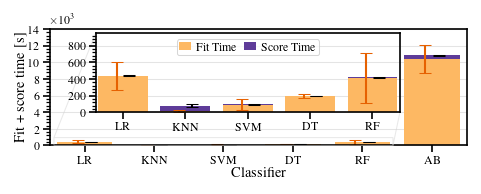

##### [Metrics](plots/classifier_metrics_randiv_pad.pdf)

<Figure size 358.544x100.724 with 0 Axes>

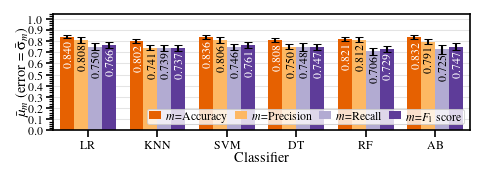

#### All “Not constrained” Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",208,"""5.0±0.0""",1.0,"""1291.0±464.7""","""30.1±24.3""","""0.898±0.029""","""0.883±0.033""","""0.862±0.042""","""0.867±0.038"""
"""KNN""",208,"""5.0±0.0""",1.0,"""48.4±40.5""","""116.3±25.6""","""0.879±0.027""","""0.853±0.029""","""0.862±0.041""","""0.855±0.036"""
"""SVM""",208,"""3.9±1.2""",0.790385,"""588.7±625.4""","""18.1±17.2""","""0.888±0.036""","""0.871±0.039""","""0.849±0.051""","""0.854±0.046"""
"""DT""",208,"""5.0±0.0""",1.0,"""352.6±76.4""","""4.3±0.7""","""0.882±0.033""","""0.860±0.037""","""0.847±0.051""","""0.851±0.043"""
"""RF""",208,"""5.0±0.0""",1.0,"""1144.2±707.9""","""51.5±64.0""","""0.872±0.029""","""0.854±0.029""","""0.851±0.047""","""0.839±0.041"""
"""AB""",208,"""5.0±0.0""",1.0,"""20973.0±4006.1""","""866.7±161.8""","""0.887±0.033""","""0.874±0.036""","""0.843±0.047""","""0.852±0.044"""


##### [Times](plots/classifier_times_eth.pdf)

<Figure size 358.544x100.724 with 0 Axes>

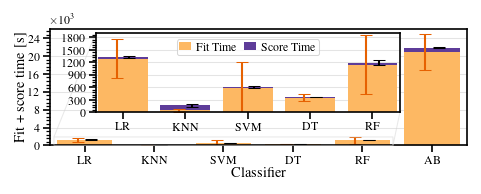

##### [Metrics](plots/classifier_metrics_eth.pdf)

<Figure size 358.544x100.724 with 0 Axes>

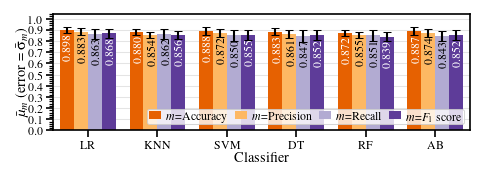

#### All SCHC Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",248,"""5.0±0.0""",1.0,"""3.9±1.2""","""0.3±0.2""","""0.851±0.019""","""0.822±0.028""","""0.756±0.037""","""0.778±0.031"""
"""KNN""",248,"""5.0±0.0""",1.0,"""1.5±0.5""","""15.9±0.3""","""0.817±0.023""","""0.755±0.030""","""0.747±0.036""","""0.748±0.032"""
"""SVM""",248,"""5.0±0.0""",1.0,"""2.3±1.2""","""0.3±0.2""","""0.852±0.018""","""0.825±0.026""","""0.755±0.036""","""0.779±0.029"""
"""DT""",248,"""5.0±0.0""",1.0,"""74.2±3.3""","""0.6±0.0""","""0.813±0.026""","""0.747±0.033""","""0.751±0.053""","""0.747±0.039"""
"""RF""",248,"""5.0±0.0""",1.0,"""6.5±1.1""","""0.5±0.1""","""0.847±0.022""","""0.846±0.024""","""0.714±0.048""","""0.762±0.038"""
"""AB""",248,"""5.0±0.0""",1.0,"""2705.8±90.8""","""118.2±3.6""","""0.843±0.018""","""0.808±0.026""","""0.731±0.040""","""0.759±0.033"""


##### [Times](plots/classifier_times_schc.pdf)

<Figure size 358.544x100.724 with 0 Axes>

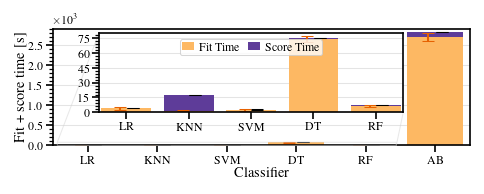

##### [Metrics](plots/classifier_metrics_schc.pdf)

<Figure size 358.544x100.724 with 0 Axes>

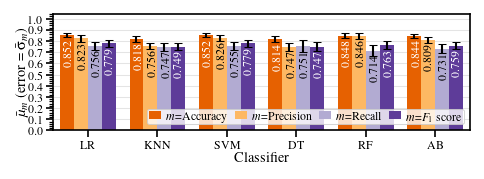

#### All Blocksize 1024 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",236,"""5.0±0.0""",1.0,"""141.1±68.0""","""2.1±1.8""","""0.869±0.016""","""0.848±0.018""","""0.854±0.024""","""0.849±0.019"""
"""KNN""",236,"""5.0±0.0""",1.0,"""9.3±4.0""","""19.4±1.3""","""0.836±0.015""","""0.796±0.016""","""0.846±0.017""","""0.820±0.016"""
"""SVM""",236,"""5.0±0.0""",1.0,"""29.9±18.1""","""0.9±0.6""","""0.869±0.017""","""0.849±0.017""","""0.853±0.024""","""0.850±0.019"""
"""DT""",236,"""5.0±0.0""",1.0,"""107.8±38.9""","""1.5±0.3""","""0.854±0.024""","""0.835±0.022""","""0.819±0.040""","""0.825±0.032"""
"""RF""",236,"""5.0±0.0""",1.0,"""109.6±39.3""","""3.3±1.8""","""0.853±0.018""","""0.836±0.017""","""0.848±0.023""","""0.835±0.021"""
"""AB""",236,"""5.0±0.0""",1.0,"""5317.4±685.9""","""233.6±22.3""","""0.857±0.022""","""0.838±0.023""","""0.835±0.030""","""0.835±0.025"""


##### [Times](plots/classifier_times_b1024.pdf)

<Figure size 358.544x100.724 with 0 Axes>

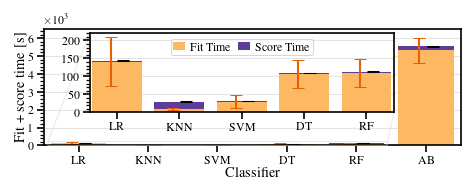

##### [Metrics](plots/classifier_metrics_b1024.pdf)

<Figure size 358.544x100.724 with 0 Axes>

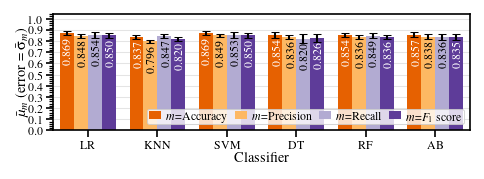

#### All Blocksize 64 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",220,"""5.0±0.0""",1.0,"""1073.6±367.9""","""26.6±21.3""","""0.876±0.032""","""0.852±0.044""","""0.751±0.055""","""0.786±0.050"""
"""KNN""",220,"""5.0±0.0""",1.0,"""37.5±34.7""","""107.0±23.1""","""0.856±0.035""","""0.804±0.044""","""0.748±0.062""","""0.773±0.053"""
"""SVM""",220,"""4.0±1.2""",0.801818,"""527.0±573.3""","""16.5±15.8""","""0.867±0.037""","""0.843±0.048""","""0.738±0.063""","""0.774±0.056"""
"""DT""",220,"""5.0±0.0""",1.0,"""301.4±34.3""","""3.1±0.4""","""0.835±0.035""","""0.759±0.049""","""0.768±0.065""","""0.761±0.051"""
"""RF""",220,"""5.0±0.0""",1.0,"""971.6±628.3""","""45.7±58.6""","""0.864±0.034""","""0.864±0.037""","""0.699±0.074""","""0.756±0.059"""
"""AB""",220,"""5.0±0.0""",1.0,"""17175.1±3154.2""","""702.1±133.0""","""0.870±0.028""","""0.838±0.039""","""0.725±0.057""","""0.765±0.053"""


##### [Times](plots/classifier_times_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

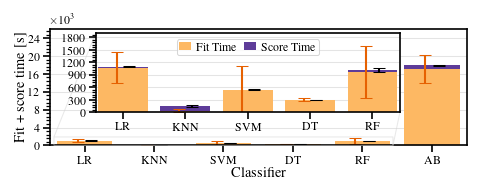

##### [Metrics](plots/classifier_metrics_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

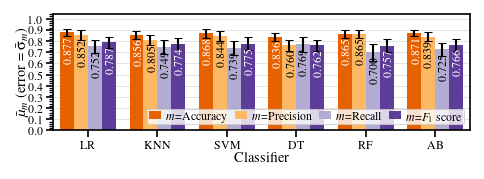

#### All SCHC and Blocksize 64 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",96,"""5.0±0.0""",1.0,"""2453.2±841.0""","""60.3±48.5""","""0.880±0.041""","""0.857±0.051""","""0.775±0.061""","""0.807±0.059"""
"""KNN""",96,"""5.0±0.0""",1.0,"""83.4±78.6""","""212.5±52.8""","""0.877±0.037""","""0.839±0.042""","""0.793±0.069""","""0.813±0.056"""
"""SVM""",96,"""2.7±0.9""",0.545833,"""1203.4±1311.6""","""37.1±35.9""","""0.858±0.055""","""0.831±0.066""","""0.745±0.081""","""0.777±0.076"""
"""DT""",96,"""5.0±0.0""",1.0,"""573.9±73.3""","""6.1±0.8""","""0.855±0.041""","""0.792±0.055""","""0.796±0.071""","""0.792±0.060"""
"""RF""",96,"""5.0±0.0""",1.0,"""2214.8±1438.1""","""103.8±134.2""","""0.870±0.042""","""0.871±0.043""","""0.729±0.086""","""0.778±0.070"""
"""AB""",96,"""5.0±0.0""",1.0,"""34791.9±7069.6""","""1413.0±300.8""","""0.873±0.036""","""0.851±0.048""","""0.754±0.063""","""0.790±0.060"""


##### [Times](plots/classifier_times_schc_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

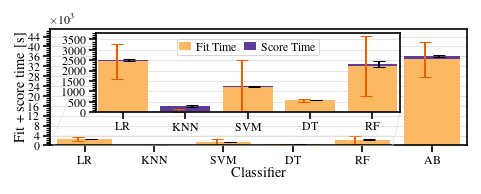

##### [Metrics](plots/classifier_metrics_schc_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

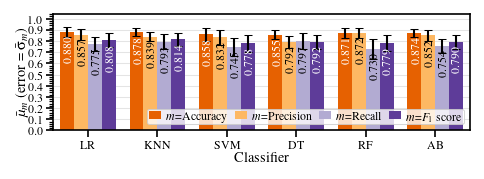

#### Base “Not constrained” Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",144,"""5.0±0.0""",1.0,"""1386.9±485.9""","""34.7±29.8""","""0.911±0.033""","""0.900±0.036""","""0.881±0.046""","""0.886±0.042"""
"""KNN""",144,"""5.0±0.0""",1.0,"""52.8±48.9""","""110.4±16.3""","""0.893±0.029""","""0.872±0.032""","""0.878±0.045""","""0.874±0.039"""
"""SVM""",144,"""4.0±1.2""",0.802778,"""751.1±832.5""","""21.9±22.4""","""0.900±0.041""","""0.888±0.044""","""0.867±0.057""","""0.872±0.051"""
"""DT""",144,"""5.0±0.0""",1.0,"""348.2±89.7""","""4.3±0.6""","""0.893±0.039""","""0.872±0.043""","""0.860±0.057""","""0.864±0.051"""
"""RF""",144,"""5.0±0.0""",1.0,"""1200.8±693.5""","""64.6±81.5""","""0.889±0.033""","""0.869±0.032""","""0.877±0.053""","""0.867±0.045"""
"""AB""",144,"""5.0±0.0""",1.0,"""20531.9±3987.3""","""839.7±153.5""","""0.901±0.039""","""0.890±0.043""","""0.865±0.050""","""0.871±0.048"""


##### [Times](plots/classifier_times_base_eth.pdf)

<Figure size 358.544x100.724 with 0 Axes>

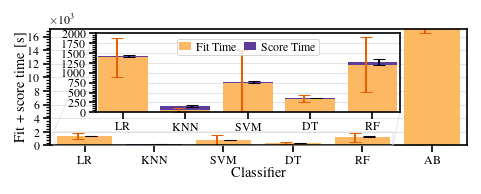

##### [Metrics](plots/classifier_metrics_base_eth.pdf)

<Figure size 358.544x100.724 with 0 Axes>

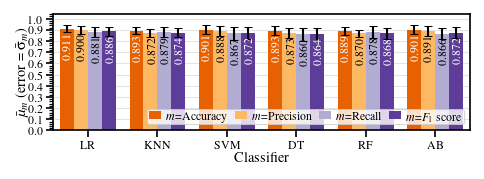

#### Base SCHC Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",152,"""5.0±0.0""",1.0,"""4.2±1.3""","""0.3±0.2""","""0.871±0.023""","""0.846±0.031""","""0.789±0.043""","""0.812±0.038"""
"""KNN""",152,"""5.0±0.0""",1.0,"""1.5±0.6""","""15.8±0.3""","""0.848±0.028""","""0.794±0.035""","""0.788±0.044""","""0.789±0.040"""
"""SVM""",152,"""5.0±0.0""",1.0,"""2.4±1.2""","""0.3±0.2""","""0.871±0.021""","""0.849±0.027""","""0.787±0.042""","""0.813±0.036"""
"""DT""",152,"""5.0±0.0""",1.0,"""70.2±2.9""","""0.6±0.0""","""0.838±0.032""","""0.781±0.038""","""0.782±0.065""","""0.779±0.048"""
"""RF""",152,"""5.0±0.0""",1.0,"""6.4±1.1""","""0.5±0.1""","""0.870±0.028""","""0.872±0.028""","""0.755±0.060""","""0.803±0.049"""
"""AB""",152,"""5.0±0.0""",1.0,"""2693.0±94.4""","""118.8±3.6""","""0.861±0.020""","""0.839±0.029""","""0.763±0.043""","""0.792±0.037"""


##### [Times](plots/classifier_times_base_schc.pdf)

<Figure size 358.544x100.724 with 0 Axes>

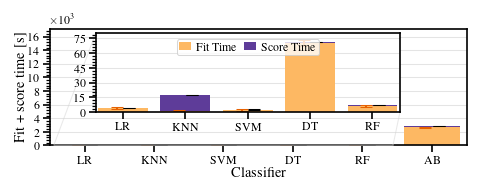

##### [Metrics](plots/classifier_metrics_base_schc.pdf)

<Figure size 358.544x100.724 with 0 Axes>

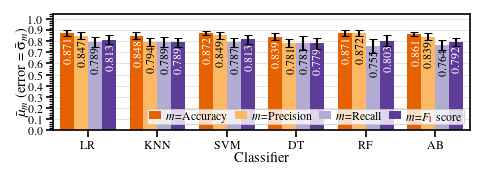

#### Base Blocksize 1024 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",156,"""5.0±0.0""",1.0,"""203.5±100.4""","""3.0±2.6""","""0.894±0.019""","""0.881±0.019""","""0.882±0.025""","""0.880±0.021"""
"""KNN""",156,"""5.0±0.0""",1.0,"""10.5±4.7""","""22.2±1.6""","""0.871±0.017""","""0.839±0.017""","""0.884±0.021""","""0.860±0.018"""
"""SVM""",156,"""5.0±0.0""",1.0,"""40.6±26.1""","""1.2±0.9""","""0.895±0.019""","""0.882±0.018""","""0.880±0.026""","""0.880±0.021"""
"""DT""",156,"""5.0±0.0""",1.0,"""117.6±55.5""","""1.6±0.2""","""0.886±0.028""","""0.876±0.023""","""0.857±0.047""","""0.865±0.038"""
"""RF""",156,"""5.0±0.0""",1.0,"""162.1±58.5""","""4.4±2.6""","""0.883±0.020""","""0.873±0.018""","""0.878±0.030""","""0.870±0.026"""
"""AB""",156,"""5.0±0.0""",1.0,"""5576.5±812.1""","""242.6±27.1""","""0.882±0.026""","""0.869±0.027""","""0.865±0.032""","""0.865±0.028"""


##### [Times](plots/classifier_times_base_b1024.pdf)

<Figure size 358.544x100.724 with 0 Axes>

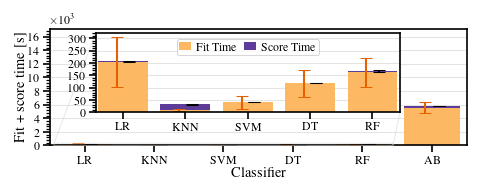

##### [Metrics](plots/classifier_metrics_base_b1024.pdf)

<Figure size 358.544x100.724 with 0 Axes>

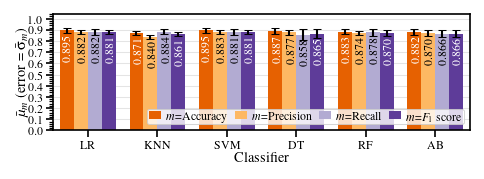

#### Base Blocksize 64 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",140,"""5.0±0.0""",1.0,"""1204.4±389.3""","""32.8±28.0""","""0.886±0.038""","""0.862±0.050""","""0.780±0.065""","""0.812±0.060"""
"""KNN""",140,"""5.0±0.0""",1.0,"""44.3±45.7""","""106.0±15.3""","""0.868±0.042""","""0.824±0.052""","""0.774±0.071""","""0.796±0.062"""
"""SVM""",140,"""3.9±1.2""",0.797143,"""730.0±828.5""","""21.6±22.4""","""0.875±0.044""","""0.852±0.054""","""0.765±0.076""","""0.799±0.068"""
"""DT""",140,"""5.0±0.0""",1.0,"""303.4±33.6""","""3.3±0.4""","""0.841±0.043""","""0.769±0.060""","""0.779±0.076""","""0.771±0.062"""
"""RF""",140,"""5.0±0.0""",1.0,"""1061.4±649.4""","""62.1±81.1""","""0.876±0.041""","""0.867±0.044""","""0.744±0.086""","""0.794±0.070"""
"""AB""",140,"""5.0±0.0""",1.0,"""17828.4±3298.7""","""722.3±131.6""","""0.878±0.033""","""0.858±0.045""","""0.754±0.062""","""0.792±0.058"""


##### [Times](plots/classifier_times_base_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

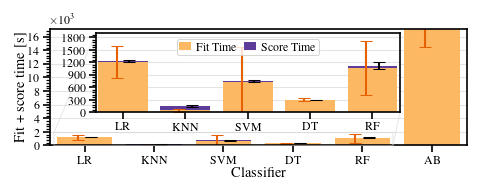

##### [Metrics](plots/classifier_metrics_base_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

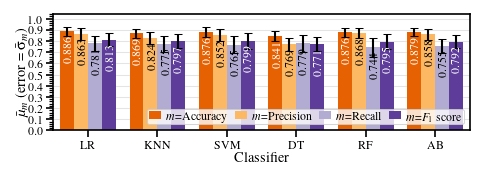

#### Base SCHC and Blocksize 64 Scenarios

classifier,count,successful_folds,full_fold_scenarios,fit_time,score_time,accuracy,precision,recall,f1_score
str,u64,str,f64,str,str,str,str,str,str
"""LR""",64,"""5.0±0.0""",1.0,"""2627.5±849.7""","""71.2±60.9""","""0.891±0.046""","""0.871±0.059""","""0.797±0.068""","""0.826±0.066"""
"""KNN""",64,"""5.0±0.0""",1.0,"""94.5±99.2""","""201.9±33.4""","""0.888±0.043""","""0.852±0.051""","""0.815±0.076""","""0.832±0.064"""
"""SVM""",64,"""2.7±0.9""",0.55625,"""1592.6±1810.4""","""46.6±48.6""","""0.866±0.064""","""0.843±0.075""","""0.763±0.093""","""0.793±0.087"""
"""DT""",64,"""5.0±0.0""",1.0,"""561.6±69.2""","""6.2±0.9""","""0.856±0.050""","""0.793±0.068""","""0.802±0.079""","""0.796±0.072"""
"""RF""",64,"""5.0±0.0""",1.0,"""2311.4±1418.9""","""135.0±177.4""","""0.884±0.051""","""0.871±0.051""","""0.779±0.097""","""0.818±0.080"""
"""AB""",64,"""5.0±0.0""",1.0,"""34873.8±7070.1""","""1400.5±283.4""","""0.884±0.042""","""0.864±0.056""","""0.780±0.063""","""0.810±0.063"""


##### [Times](plots/classifier_times_base_schc_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

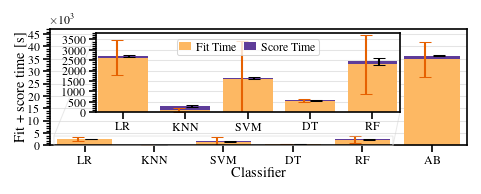

##### [Metrics](plots/classifier_metrics_base_schc_b64.pdf)

<Figure size 358.544x100.724 with 0 Axes>

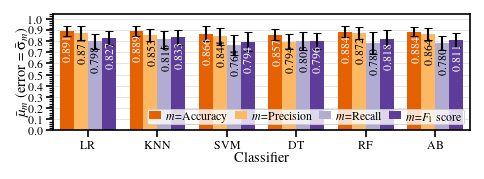

In [11]:
matplotlib.style.use("mlenders_column.mplstyle")

matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.1,
    matplotlib.rcParams["figure.figsize"][1] * 1,
)
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ['#e66101','#fdb863','#b2abd2','#5e3c99'],
    # ['#b35806','#f1a340','#fee0b6','#d8daeb','#998ec3','#542788'],
)
matplotlib.rcParams["hatch.color"] = "white"
matplotlib.rcParams["hatch.linewidth"] = 1
matplotlib.rcParams["legend.borderpad"] = 0.2
matplotlib.rcParams["legend.title_fontsize"] = "x-small"


TIMES_READABLE = {
    "fit_time": "Fit Time",
    "score_time": "Score Time",
}
METRICS_READABLE = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "$F_1$ score",
    # "balanced_accuracy": "Balanced Accuracy",
    # "roc_auc": "ROC Curve AUC",
}
CLASSIFIERS = [
    "lr",
    "knn",
    "svm",
    "dt",
    "rf",
    "ab",
]
SCHEMA_OVERRIDES = {
    "blocksize": polars.Int16,
    "k": polars.Int8,
    "randiv_pad": polars.Int8,
    "job_id": polars.Int64,
}
PLOTS = {
    "times": TIMES_READABLE,
    "metrics": METRICS_READABLE,
}
COLORS = {
    "metrics": [f"C{c}" for c in range(len(METRICS_READABLE))],
}
SHORT_TIME_YSCALE = {
    "": (0, 951, 200),
    "_base":  (0, 951, 200),
    "_randiv_pad":  (0, 951, 200),
    "_eth":  (0, 1901, 300),
    "_schc":  (0, 81, 15),
    "_b1024":  (0, 221, 50),
    "_b64":  (0, 1901, 300),
    "_schc_b64":  (0, 3801, 500),
    "_base_eth":  (0, 2001, 250),
    "_base_schc":  (0, 81, 15),
    "_base_b1024":  (0, 321, 50),
    "_base_b64":  (0, 1901, 300),
    "_base_schc_b64":  (0, 3801, 500),
}
LONG_TIME_YSCALE = {
    "": (0, 14001, 2000),
    "_base": (0, 14001, 2000), 
    "_randiv_pad": (0, 14001, 2000),
    "_eth": (0, 26001, 4000),
    "_schc": (0, 2901, 500),
    "_b1024": (0, 6501, 1000),
    "_b64": (0, 26001, 4000),
    "_schc_b64": (0, 47001, 4000),
    "_base_eth": (0, 17101, 2000),
    "_base_schc":  (0, 17101, 2000),
    "_base_b1024": (0, 17101, 2000),
    "_base_b64": (0, 17101, 2000),
    "_base_schc_b64": (0, 47001, 5000),
}


for slice_name, outfile_suffix, file_filter in [
    ("All Scenarios", "", lambda p: True),
    ("Base Scenarios", "_base", lambda p: "_randiv_pad" not in p.name),
    ("Random IV/Padding Scenarios", "_randiv_pad", lambda p: "_randiv_pad" in p.name),
    ("All “Not constrained” Scenarios", "_eth", lambda p: "-schc" not in p.name),
    ("All SCHC Scenarios", "_schc", lambda p: "-schc" in p.name),
    ("All Blocksize 1024 Scenarios", "_b1024", lambda p: "_b64" not in p.name),
    ("All Blocksize 64 Scenarios", "_b64", lambda p: "_b64" in p.name),
    ("All SCHC and Blocksize 64 Scenarios", "_schc_b64", lambda p: "_b64" in p.name and "-schc" not in p.name),
    ("Base “Not constrained” Scenarios", "_base_eth", lambda p: "_randiv_pad" not in p.name and "-schc" not in p.name),
    ("Base SCHC Scenarios", "_base_schc", lambda p: "_randiv_pad" not in p.name and "-schc" in p.name),
    ("Base Blocksize 1024 Scenarios", "_base_b1024", lambda p: "_randiv_pad" not in p.name and "_b64" not in p.name),
    ("Base Blocksize 64 Scenarios", "_base_b64", lambda p: "_randiv_pad" not in p.name and "_b64" in p.name),
    (
        "Base SCHC and Blocksize 64 Scenarios",
        "_base_schc_b64",
        lambda p: "_randiv_pad" not in p.name and "_b64" in p.name and "-schc" not in p.name
    ),
]:
    lf = polars.concat(
        map(
            lambda file: polars.scan_csv(
                file,
                separator=";",
                schema_overrides=SCHEMA_OVERRIDES,
            ),
            [
                p for p in INPUT_PATH.glob("*.cross_val.csv")
                if file_filter(p)
            ]
        )
    ).with_columns(
        *[
            polars.col(col)
                .str.strip_chars_start("[")
                .str.strip_chars_end("]")
                .str.split(",")
                .list.eval(polars.element().str.strip_chars(" "))
                .cast(polars.List(polars.Float64))
            for col in list(TIMES_READABLE) + list(METRICS_READABLE)
        ]
    ).explode(
        list(TIMES_READABLE) + list(METRICS_READABLE)
    ).drop_nans(list(METRICS_READABLE)).group_by(
        polars.exclude(list(TIMES_READABLE) + list(METRICS_READABLE))
    ).agg(
        polars.col("fit_time").count().alias("successful_folds"),
        *[
            polars.col(col).mean().alias(f"{col}_mean")
            for col in list(TIMES_READABLE) + list(METRICS_READABLE)
        ],
        *[
            polars.col(col).std().alias(f"{col}_std")
            for col in list(TIMES_READABLE) + list(METRICS_READABLE)
        ],
    ).select(
        ["classifier", "successful_folds"] + [
            f"{col}_mean"
            for col
            in list(TIMES_READABLE) + list(METRICS_READABLE)
        ] + [
            f"{col}_std"
            for col
            in list(TIMES_READABLE) + list(METRICS_READABLE)
        ]
    ).group_by("classifier").agg(
        *(
            [
                polars.col("classifier").count().alias("count"),
                polars.col("successful_folds").sum().alias("successful_folds_count"),
                polars.col("successful_folds").mean().alias("successful_folds_mean"),
                polars.col("successful_folds").std().alias("successful_folds_std"),
            ] + [
                polars.col(f"{col}_mean").mean() 
                for col
                in list(TIMES_READABLE) + list(METRICS_READABLE)
            ] + [
                polars.col(f"{col}_std").mean() 
                for col
                in list(TIMES_READABLE) + list(METRICS_READABLE)
            ]
        )
    )
    
    
    BAR_WIDTH = 0.2
    
    
    display(Markdown(f"#### {slice_name}"))
    display(
        lf.with_columns(
            cls_index=polars.col("classifier").map_elements(
                lambda c: CLASSIFIERS.index(c),
                return_dtype=polars.Int8,
            )
        ).sort("cls_index").select(
            ["classifier", "count", "successful_folds_count"] + [
                polars.col(f"{col}_mean").cast(
                    polars.Decimal(scale=1 if col.endswith("_time") or col.endswith("_folds") else 3)
                ).cast(polars.String())
                for col
                in ["successful_folds"] + list(TIMES_READABLE) + list(METRICS_READABLE)
            ] + [
                polars.col(f"{col}_std").cast(
                    polars.Decimal(scale=1 if col.endswith("_time") or col.endswith("_folds") else 3)
                ).cast(polars.String())
                for col
                in ["successful_folds"] + list(TIMES_READABLE) + list(METRICS_READABLE)
            ]
        ).with_columns(
            polars.col("classifier").str.to_uppercase(),
            *[
                polars.concat_str(
                    [
                        polars.col(f"{col}_mean"),
                        polars.col(f"{col}_std"),
                    ],
                    separator="±",
                ).alias(col)
                for col
                in ["successful_folds"] + list(TIMES_READABLE) + list(METRICS_READABLE)
            ],
            full_fold_scenarios=(
                polars.col("successful_folds_count") / polars.col("count") / 5
            )
        ).select(
            ["classifier", "count", "successful_folds", "full_fold_scenarios"] + list(TIMES_READABLE) + list(METRICS_READABLE)
        ).collect()
    )
    
    for plot in PLOTS:
        df = lf.with_columns(
            cls_index=polars.col("classifier").map_elements(
                lambda c: CLASSIFIERS.index(c),
                return_dtype=polars.Int8,
            )
        ).sort("cls_index").select(
            ["classifier"] + [
                f"{key}_mean" for key in PLOTS[plot]
            ] + [
                f"{key}_std" for key in PLOTS[plot]
            ]
        ).collect()
        index = numpy.arange(df.shape[0])
        matplotlib.pyplot.gcf()
        fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
        ax = matplotlib.pyplot.gca()
    
        if plot == "times":
            short_scale = SHORT_TIME_YSCALE.get(outfile_suffix, SHORT_TIME_YSCALE[""])
            matplotlib.rcParams["hatch.color"] = "white"
            if (
                df.filter(polars.col("classifier") == "ab").is_empty()
                or not df.filter(
                    (polars.col("classifier") == "ab") &
                    (polars.col("fit_time_mean") < 500)
                ).is_empty()
            ):
                axs = [ax]
            else:
                axins = ax.inset_axes(
                    [0.11, 0.285, 0.73, 0.680],
                    xlim=(-0.44, len(CLASSIFIERS) - 1.56),
                    ylim=(short_scale[0], short_scale[1] - 1),
                    yticks=numpy.arange(*short_scale)
                )
                axs = [ax, axins]
            for a in axs:
                a.set_axisbelow(True)
                a.grid(axis="y", color="lightgray")
                a.bar(
                    df["classifier"].str.to_uppercase(),
                    df["fit_time_mean"],
                    color="C1",
                    label=TIMES_READABLE["fit_time"],
                    width=BAR_WIDTH * len(METRICS_READABLE),
                )
                a.errorbar(
                    index - 0.1,
                    df["fit_time_mean"],
                    yerr=df["fit_time_std"],
                    color="C0",
                    linewidth=0,
                    elinewidth=1,
                    capsize=3,
                )
                a.bar(
                    df["classifier"].str.to_uppercase(),
                    df["score_time_mean"],
                    bottom=df["fit_time_mean"],
                    color="C3",
                    label=TIMES_READABLE["score_time"],
                    width=BAR_WIDTH * len(METRICS_READABLE),
                )
                a.errorbar(
                    index + 0.1,
                    df["fit_time_mean"] + df["score_time_mean"],
                    yerr=df["score_time_std"],
                    color="black",
                    linewidth=0,
                    elinewidth=1,
                    capsize=3,
                )
            
            ax.set_ylabel("Fit + score time [s]")
            if len(axs) == 1:
                ax.set_ylim(0, short_scale[1] - 1)
                ax.set_yticks(numpy.arange(*short_scale))
                ax.set_yticks(numpy.arange(*short_scale), minor=True)
                ax.legend(
                    loc="upper center",
                    ncol=2,
                )
            else:
                long_scale = LONG_TIME_YSCALE.get(outfile_suffix, LONG_TIME_YSCALE[""])
                indicate_insets = ax.indicate_inset_zoom(axins, edgecolor="lightgray")
                indicate_insets.connectors[0].set(visible=False)
                indicate_insets.connectors[1].set(visible=True)
                indicate_insets.connectors[2].set(visible=True)
                indicate_insets.connectors[3].set(visible=False)
                ax.set_ylim(0, long_scale[1] - 1)
                ax.set_yticks(numpy.arange(*long_scale))
                ax.set_yticks(
                    numpy.arange(long_scale[0], long_scale[1], long_scale[2] / 5),
                    minor=True,
                )
                ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
                axins.set_yticks(numpy.arange(*short_scale), numpy.arange(*short_scale))
                axins.set_yticks(
                    numpy.arange(short_scale[0], short_scale[1], short_scale[2] / 5),
                    minor=True,
                )
                axins.legend(
                    loc="upper center",
                    ncol=2,
                    bbox_to_anchor=None if outfile_suffix != "_base" else (0.5, 0.8),
                )
        else:
            matplotlib.rcParams["hatch.color"] = "lightgray"
            ax.set_axisbelow(True)
            ax.grid(axis="y", color="lightgray")
            for x, metric in enumerate(METRICS_READABLE):
                ax.bar(
                    index - (1.5 * BAR_WIDTH) + (x * BAR_WIDTH),
                    df[f"{metric}_mean"],
                    width = BAR_WIDTH,
                    label = f"$m$={METRICS_READABLE[metric]}",
                    #hatch = "////" if x % 2 else "----",
                )
                ax.errorbar(
                    index - (1.5 * BAR_WIDTH) + (x * BAR_WIDTH),
                    df[f"{metric}_mean"],
                    df[f"{metric}_std"],
                    color="black",
                    linewidth=0,
                    elinewidth=1,
                    capsize=2,
                )
                i_offset = 0
                for cls_idx, i in enumerate(index - (1.5 * BAR_WIDTH) + (x * BAR_WIDTH)):
                    cls_df = df.filter(
                        polars.col("classifier") == CLASSIFIERS[cls_idx]
                    )
                        
                    if cls_df.is_empty():
                        i_offset += 1
                        continue
                    i -= i_offset
                    y = cls_df[f"{metric}_mean"][0]
                    ax.text(
                        i + 0.02,
                        y - 0.04,
                        rf"{y:.3f}\strut",
                        fontsize="xx-small",
                        rotation=90,
                        ha="center",
                        va="top" if y > 0.002 else "bottom",
                        color="white" if y > 0.002 and metric in ["accuracy", "f1_score"] else "black",
                    )
                ax.set_ylabel(r"$\bar\mu_m$ (error = $\bar\sigma_m$)")
                ax.set_ylim(0, 1.02)
                ax.set_yticks(numpy.arange(0.0, 1.1, 0.1))
                ax.set_yticks(numpy.arange(0.0, 1.05, 0.02), minor=True)
                ax.set_xticks(index, df["classifier"].str.to_uppercase())
                ax.legend(loc="lower right", ncol=4)
        ax.set_xlim(-0.5, len(CLASSIFIERS) - 0.5)
        ax.set_xlabel("Classifier")
        filename = EVALUATION_PATH / "plots" / f"classifier_{plot.replace(" ", "_")}{outfile_suffix}.pdf"
        matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
        display(Markdown(f"##### [{plot.title()}]({filename.relative_to(EVALUATION_PATH)})"))
        matplotlib.pyplot.show()

### Missing Scenarios

In [12]:
CLASSIFIERS = [
    "lr",
    "knn",
    "svm",
    "dt",
    "rf",
    "ab",
]
CLASSIFIER_READABLE = {
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest (Ensemble Learning III)",
    "ab": "AdaBoost (SAMME)"
}

for cls in CLASSIFIERS:
    missing = []
    for scenario in list_scenarios():
        path = INPUT_PATH / f"{scenario}.cross_val.csv"
        if not path.exists():
            missing.append(scenario)
            continue
        lf = polars.scan_csv(path, separator=";")
        if lf.filter(polars.col("classifier") == cls).collect().is_empty():
            missing.append(scenario)
    display(Markdown(f"#### {CLASSIFIER_READABLE[cls]}, Missing: {len(missing)}\n" + "\n".join(f" - {scenario}" for scenario in missing)))

#### Logistic Regression, Missing: 0


#### K-Nearest Neighbors, Missing: 0


#### Support Vector Machine, Missing: 0


#### Decision Tree, Missing: 0


#### Random Forest (Ensemble Learning III), Missing: 0


#### AdaBoost (SAMME), Missing: 0


## Full Grid Plots

Here, we generate the plots we show in Appendix A of the paper for RF, but also for all other classifiers, as well as the artificially generated scenarios with random Partial IV / cipher nonce and padding.

In [13]:
SCHEMA_OVERRIDES = {
    "blocksize": polars.Int16,
    "k": polars.Int8,
    "randiv_pad": polars.Int8,
    "job_id": polars.Int64,
}
TIMES_READABLE = {
    "fit_time": "Fit Time",
    "score_time": "Score Time",
}
METRICS_READABLE = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "$F_1$ score",
    "balanced_accuracy": "Balanced Accuracy",
    "roc_auc": "ROC Curve AUC",
}

files = []
for vector in FEATURE_VECTORS:
    for scenario in list_scenarios():
        file = INPUT_PATH / f"{scenario}.cross_val.csv"
        if file.exists() and file.stat().st_size > 0:
            files.append(file)


lf = polars.concat(
    map(
        lambda f: polars.scan_csv(
            f,
            schema_overrides=SCHEMA_OVERRIDES,
            separator=";",
        ),
        files,
    )
).with_columns(
    *[
        polars.col(col)
            .str.strip_chars_start("[")
            .str.strip_chars_end("]")
            .str.split(",")
            .list.eval(polars.element().str.strip_chars(" "))
            .cast(polars.List(polars.Float64))
        for col in list(TIMES_READABLE) + list(METRICS_READABLE)
    ]
)
CLASSIFIERS = [
    #"lr",
    #"knn",
    #"svm",
    #"dt",
    "rf"
    #"ab",
]

CLASSIFIER_READABLE = {
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest (Ensemble Learning III)",
    "ab": "AdaBoost (SAMME)"
}
LINK_LAYER_MORE_READABLE = {
    "eth": "“Ethernet”",
    "schc": "SCHC",
}


agg = {
    (vector, randiv_pad): {
        cls: {
            metric: {
                (f"{data}-{dns}", prot.replace("oscore-base", "oscore_base"), stp): {}
                for data in DATA_FORMATS
                for dns in DNS_FORMATS
                for blk in BLOCKWISE
                for prot in (["coaps", "oscore"] if randiv_pad == 1 else PROTOCOLS)
                for stp in NETWORK_SETUPS
            }
            for metric in METRICS_READABLE
        }
        for cls in CLASSIFIERS
    }
    for vector in FEATURE_VECTORS
    for randiv_pad in [0, 1]
}


if lf.filter(polars.col("classifier") == "svm").collect().is_empty():
    CLASSIFIERS.remove("svm")

lf = lf.with_columns(polars.col("link_layer_mode").fill_null(""))


for vector, cls, metric, (_, prot, l2, stp, l2_mode, data, dns, blk, randiv_pad) in tqdm(
    list(
        itertools.product(
            FEATURE_VECTORS,
            CLASSIFIERS,
            METRICS_READABLE,
            list_scenarios_full(),
        )
    )
):
    sub_df = lf.filter(
        (polars.col("data_format") == data)
        & (polars.col("dns_format") == dns)
        & (polars.col("vector_type") == vector)
        & (polars.col("link_layer") == LINK_LAYER_READABLE[l2])
        & (polars.col("link_layer_mode") == LINK_LAYER_MODE_READABLE[l2_mode])
        & (polars.col("protocol") == prot)
        & (polars.col("blocksize") == int(BLOCKWISE_READABLE[blk]))
        & (polars.col("network_setup") == stp)
        & (polars.col("classifier") == cls)
        & (polars.col("randiv_pad") == int(randiv_pad == "_randiv_pad"))
    ).with_columns(
        polars.col(metric).list.mean()
    ).select(metric).collect()
    agg[vector, int(randiv_pad == "_randiv_pad")][cls][metric][
        (f"{data}-{dns}", prot.replace("oscore-base", "oscore_base"), stp)
    ][l2, l2_mode, blk] = sub_df[metric][0]
    del sub_df
    setup_dict = agg[vector, int(randiv_pad == "_randiv_pad")][cls][metric][
        (f"{data}-{dns}", prot.replace("oscore-base", "oscore_base"), stp)
    ]
    if l2 == "-schc" and (l2, "-min-rules", blk) not in setup_dict:
        setup_dict[l2, "-min-rules", blk] = setup_dict[l2, "", blk]
    if l2 == "-schc" and (l2, "-peer-based", blk) not in setup_dict:
        setup_dict[l2, "-peer-based", blk] = setup_dict[l2, "", blk]

  0%|          | 0/2736 [00:00<?, ?it/s]

### Binary Vector (Base Scenarios)

#### Random Forest (Ensemble Learning III)

##### [Accuracy](plots/binvec_rf_accuracy.pdf) (minimum: 0.693)

<Figure size 358.544x100.724 with 0 Axes>

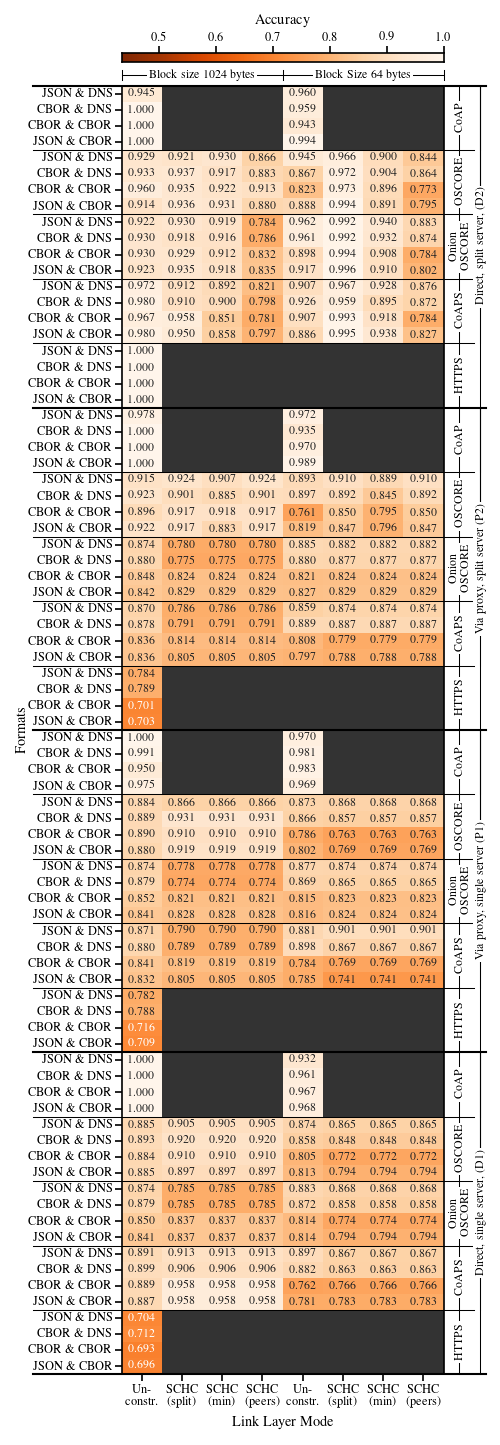

##### [Precision](plots/binvec_rf_precision.pdf) (minimum: 0.657)

<Figure size 277.057x1336.39 with 0 Axes>

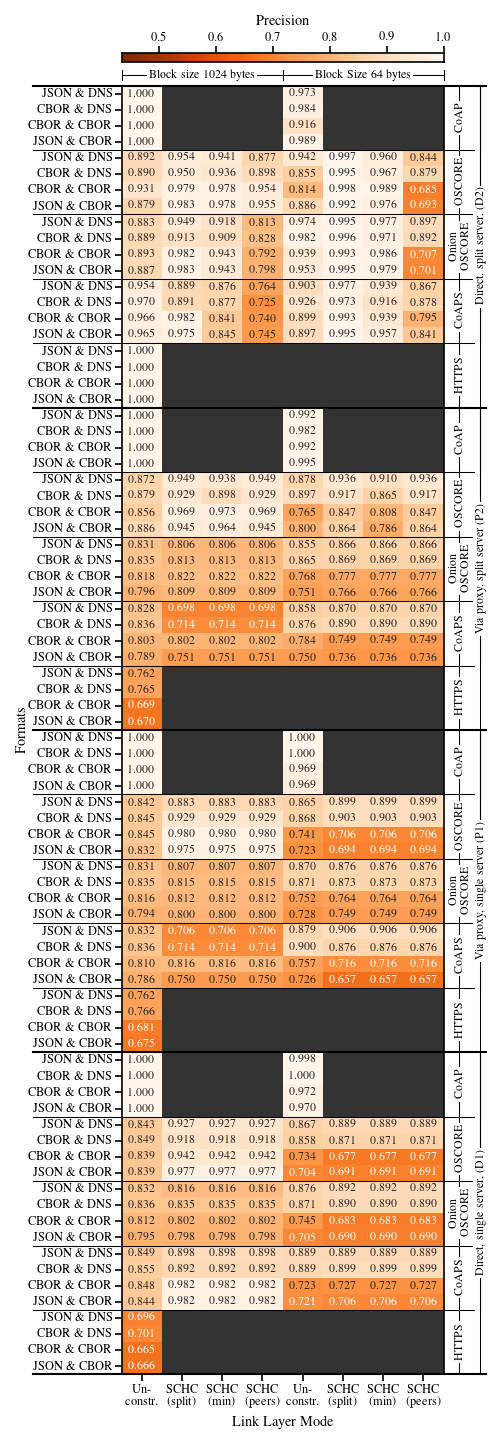

##### [Recall](plots/binvec_rf_recall.pdf) (minimum: 0.434)

<Figure size 277.057x1336.39 with 0 Axes>

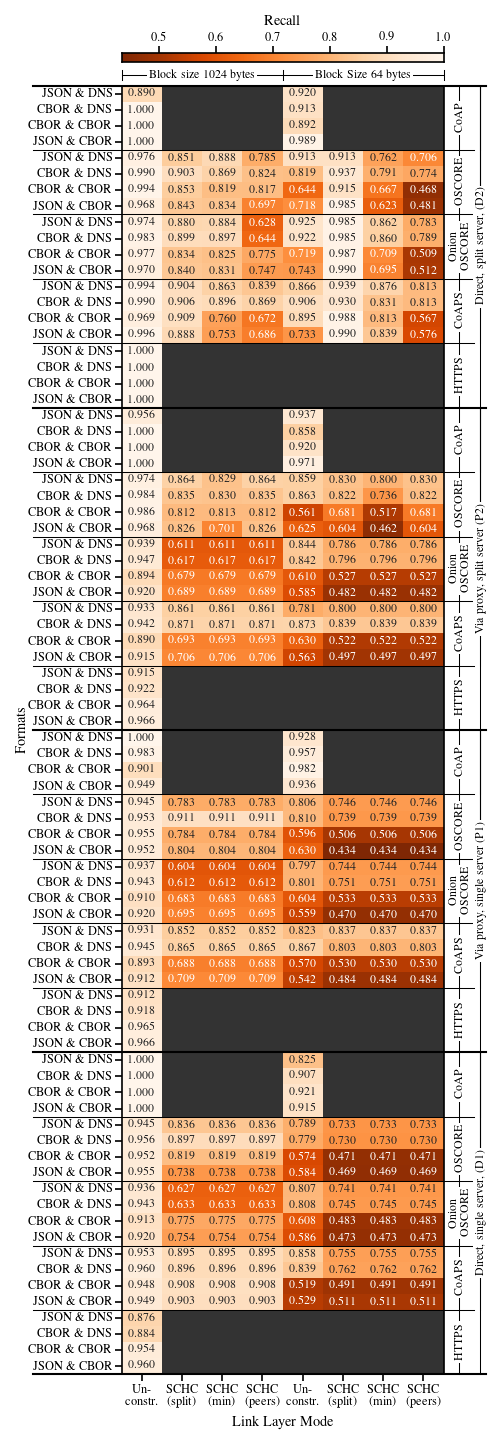

##### [$F_1$ score](plots/binvec_rf_f1_score.pdf) (minimum: 0.510)

<Figure size 277.057x1336.39 with 0 Axes>

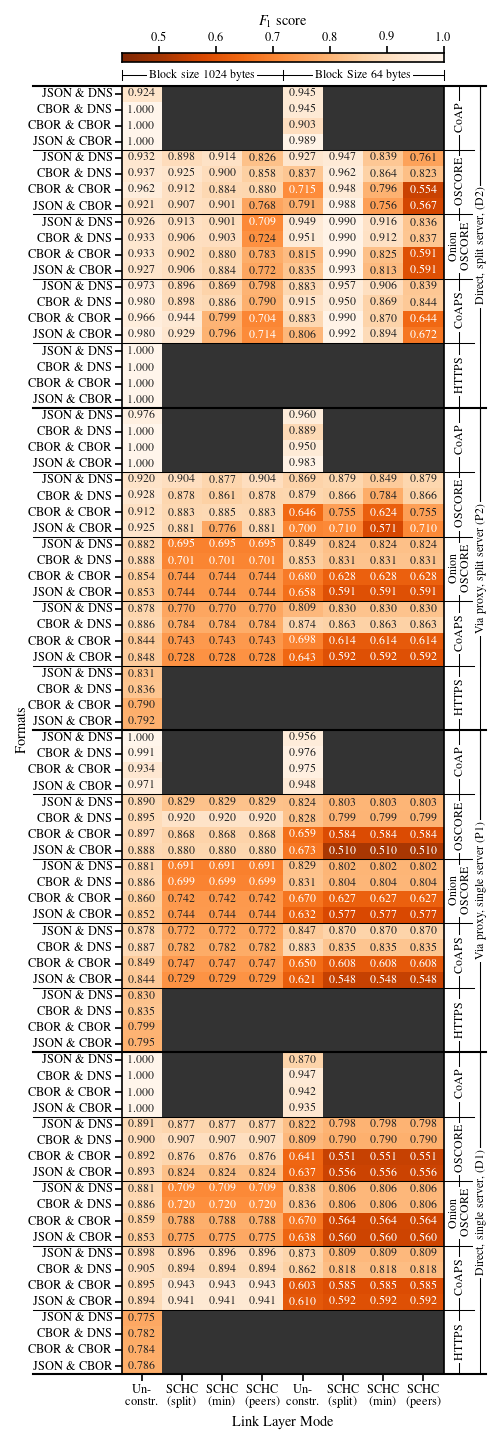

##### [Balanced Accuracy](plots/binvec_rf_balanced_accuracy.pdf) (minimum: 0.640)

<Figure size 277.057x1336.39 with 0 Axes>

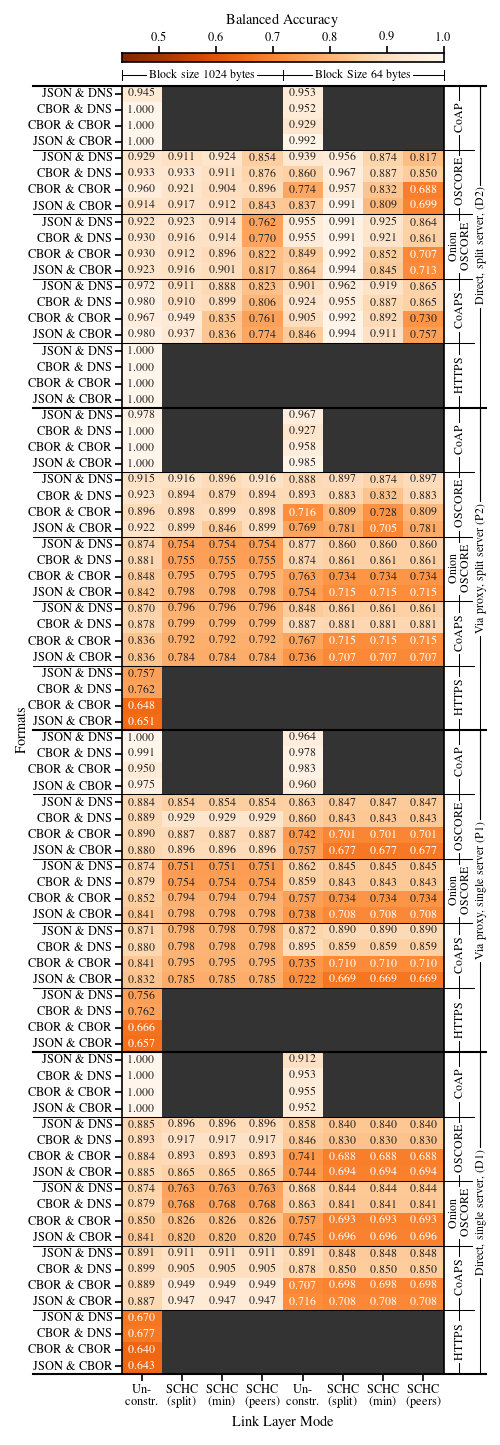

##### [ROC Curve AUC](plots/binvec_rf_roc_auc.pdf) (minimum: 0.682)

<Figure size 277.057x1336.39 with 0 Axes>

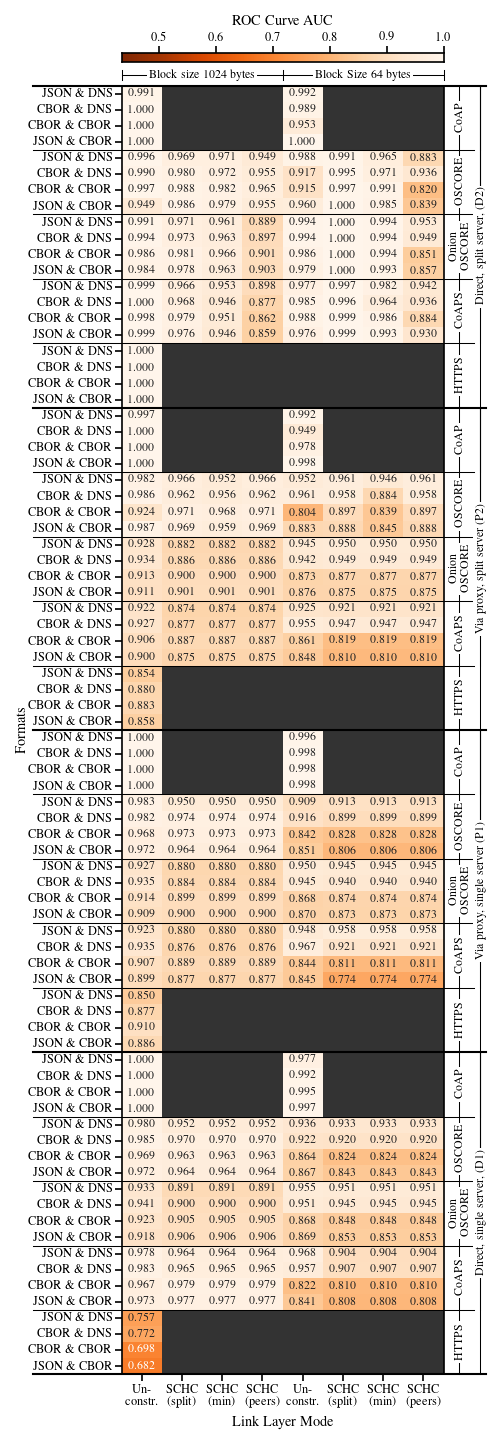

### Binary Vector (Random IV/Padding Scenarios)

#### Random Forest (Ensemble Learning III)

##### [Accuracy](plots/binvec_rf_accuracy_randiv_pad.pdf) (minimum: 0.641)

<Figure size 277.057x1336.39 with 0 Axes>

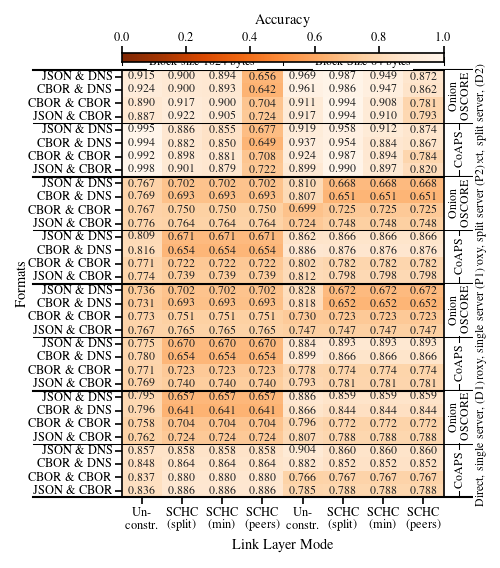

##### [Precision](plots/binvec_rf_precision_randiv_pad.pdf) (minimum: 0.585)

<Figure size 277.057x443.291 with 0 Axes>

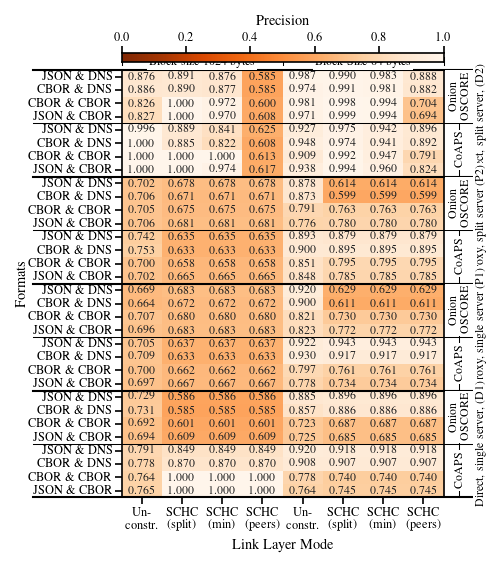

##### [Recall](plots/binvec_rf_recall_randiv_pad.pdf) (minimum: 0.018)

<Figure size 277.057x443.291 with 0 Axes>

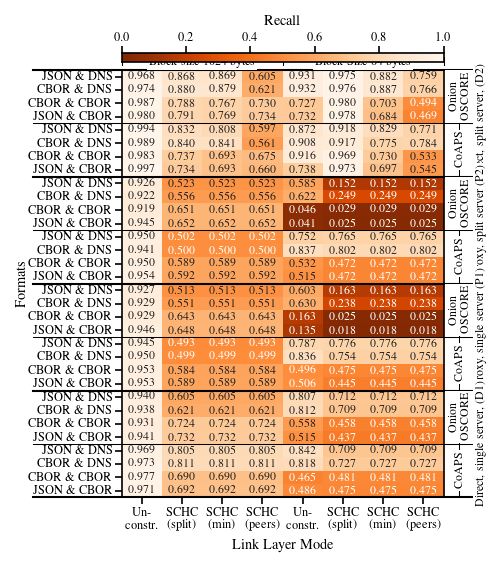

##### [$F_1$ score](plots/binvec_rf_f1_score_randiv_pad.pdf) (minimum: 0.036)

<Figure size 277.057x443.291 with 0 Axes>

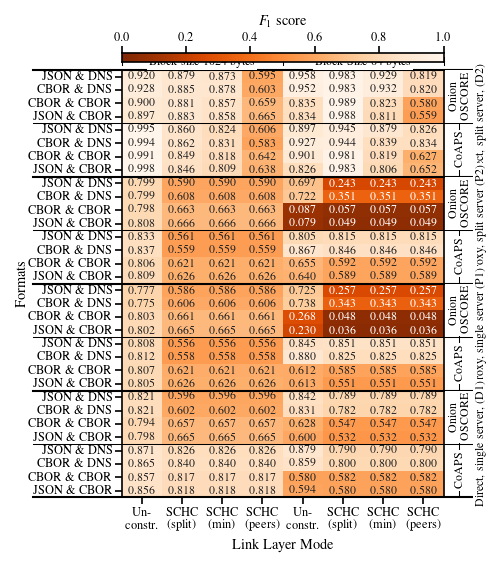

##### [Balanced Accuracy](plots/binvec_rf_balanced_accuracy_randiv_pad.pdf) (minimum: 0.508)

<Figure size 277.057x443.291 with 0 Axes>

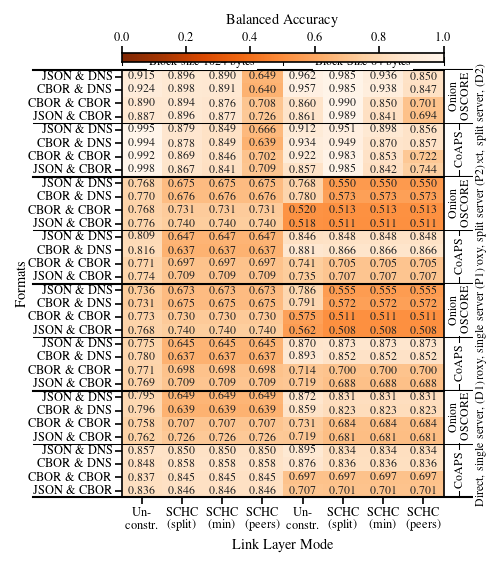

##### [ROC Curve AUC](plots/binvec_rf_roc_auc_randiv_pad.pdf) (minimum: 0.688)

<Figure size 277.057x443.291 with 0 Axes>

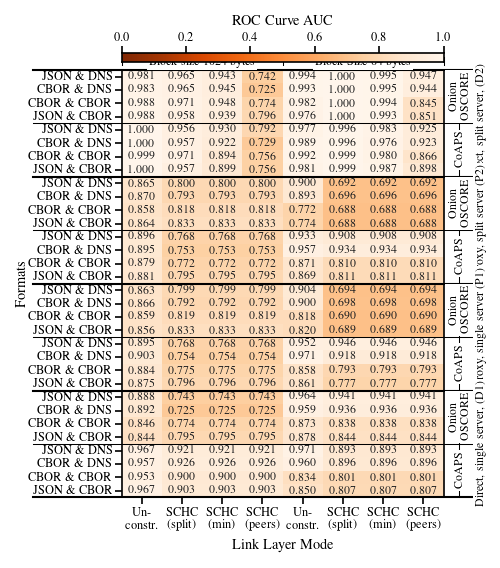

In [14]:
XTICKS_READABLE = {
    "--": "Un-\nconstr.",
    "-schc--": "SCHC\n(split)",
    "-schc--min-rules-": "SCHC\n(min)",
    "-schc--peer-based-": "SCHC\n(peers)",
    "--_b64": "Un-\nconstr.",
    "-schc--_b64": "SCHC\n(split)",
    "-schc--min-rules-_b64": "SCHC\n(min)",
    "-schc--peer-based-_b64": "SCHC\n(peers)",
}
UNTESTED_SCENARIOS = (
    (("json-dns_message", "https", "d1"), ("-schc", "", "")),
)
HEATMAP_CMAP = matplotlib.colormaps["Oranges_r"]
LINE_CMAP = matplotlib.colormaps['Oranges']

ORDER = {
    0: {
        "setup": ["d2", "p2", "p1", "d1"],
        "protocol": ["coap", "oscore_base", "oscore", "coaps", "https"],
        "formats": ["json-dns_message", "cbor-dns_message", "cbor-dns_cbor", "json-dns_cbor"],
    },
    1: {
        "setup": ["d2", "p2", "p1", "d1"],
        "protocol": ["oscore", "coaps"],
        "formats": ["json-dns_message", "cbor-dns_message", "cbor-dns_cbor", "json-dns_cbor"],
    },
}
INDEX_ORDER = ["setup", "protocol", "formats"]
INDEX_READABLE = {
    "setup": {
        "d1": "Direct, single server, (D1)",
        "d2": "Direct, split server, (D2)",
        "p1": "Via proxy, single server (P1)",
        "p2": "Via proxy, split server (P2)",
    },
    "protocol": PROTOCOLS_READABLE,
    "formats": {
        "json-dns_message": r"JSON \& DNS",
        "json-dns_cbor": r"JSON \& CBOR",
        "cbor-dns_message": r"CBOR \& DNS",
        "cbor-dns_cbor": r"CBOR \& CBOR",
    }
}
RANDIV_PAD_READABLE = [
    "Base",
    "Random IV/Padding",
]
RANDIV_PAD_SUFFIX = [
    "",
    "_randiv_pad",
]


def sort_index(idx):
    if idx.name in ORDER[0]:
        for i, _ in enumerate(idx):
            idx[i] = ORDER[0][idx.name].index(idx[i])
    return idx


for vector, randiv_pad in agg:
    if vector != "binvec":
        continue
    display(Markdown(f"### {FEATURE_VECTOR_READABLE[vector]} ({RANDIV_PAD_READABLE[randiv_pad]} Scenarios)"))
    for cls in agg[vector, randiv_pad]:
        display(Markdown(f"#### {CLASSIFIER_READABLE[cls]}"))
        for metric in agg[vector, randiv_pad][cls]:
            matplotlib.pyplot.clf()
            matplotlib.style.use("mlenders_column.mplstyle")
            
            matplotlib.rcParams["figure.figsize"] = (
                matplotlib.rcParams["figure.figsize"][0] * 0.85,
                matplotlib.rcParams["figure.figsize"][0] * 1.36
                if randiv_pad
                else matplotlib.rcParams["figure.figsize"][0] * 4.1,
            )
            matplotlib.rcParams["xtick.labelsize"] = 6
            matplotlib.rcParams["ytick.labelsize"] = 6
            order = ORDER[randiv_pad]
            
            df = pandas.DataFrame(agg[vector, randiv_pad][cls][metric]).T
            df = df.apply(
                lambda series: pandas.Series(
                    {
                        k: v if v is not None else numpy.nan
                        for k, v in series.to_dict().items()
                    }
                )
            ).sort_values(
                [
                    ("", "", ""),
                    ("-schc", "", ""),
                    ("-schc", "-min-rules", ""),
                    ("-schc", "-peer-based", ""),
                    ("", "", "_b64"),
                    ("-schc", "", "_b64"),
                    ("-schc", "-min-rules", "_b64"),
                    ("-schc", "-peer-based", "_b64"),
                ],
                ascending=False,
            )[
                [
                    ("", "", ""),
                    ("-schc", "", ""),
                    ("-schc", "-min-rules", ""),
                    ("-schc", "-peer-based", ""),
                    ("", "", "_b64"),
                    ("-schc", "", "_b64"),
                    ("-schc", "-min-rules", "_b64"),
                    ("-schc", "-peer-based", "_b64"),
                ]
            ].rename_axis(["formats", "protocol", "setup"])
            
            fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
            df = df.reset_index().sort_values(
                [
                    ("", "", ""),
                    ("-schc", "", ""),
                    ("-schc", "-min-rules", ""),
                    ("-schc", "-peer-based", ""),
                    ("", "", "_b64"),
                    ("-schc", "", "_b64"),
                    ("-schc", "-min-rules", "_b64"),
                    ("-schc", "-peer-based", "_b64"),
                ],
                ascending=False,
            ).sort_values(
                INDEX_ORDER,
                key=sort_index,
            ).set_index(["setup", "protocol", "formats"])
            ax = seaborn.heatmap(
                df,
                annot=True,
                annot_kws={"size": "xx-small", "ha": "center", "va": "center"},
                fmt=".3f",
                cbar_kws={
                    "location": "top",
                    "pad": 0.015,
                    "aspect": 35,
                },
                cmap=HEATMAP_CMAP,
                xticklabels=True,
                yticklabels=True,
                vmin=.434 if randiv_pad == 0 else 0,
                vmax=1.00,
            )
            ax.collections[0].colorbar.set_label(
                fr"{METRICS_READABLE[metric]}",
                labelpad=3.9,
            )
            ax.set_facecolor('#333333')
            seaborn.despine(fig=None, ax=None, top=False, right=False, left=False, bottom=False, offset=None, trim=False)
            ax.set_xticks(
                ax.get_xticks(),
                [XTICKS_READABLE[l.get_text()] for l in ax.get_xticklabels()],
                rotation=0,
                va="top",
            )
            ax.set_yticks(
                ax.get_yticks(),
                [
                    INDEX_READABLE[INDEX_ORDER[2]][
                        order[INDEX_ORDER[2]][i % len(order[INDEX_ORDER[2]])]
                    ]
                    for i, l in enumerate(ax.get_yticklabels())
                ],
            )
            ax.set_xlabel("Link Layer Mode", labelpad=4.5)
            ax.set_ylabel("Formats")

            last_prot = None
            last_setup = None
            for ytick in list(ax.get_yticks()) + [max(ax.get_yticks()) + 1]:
                ytick -= .5
                if (ytick % len(order[INDEX_ORDER[2]])) == 0:
                    x0 = ax.get_xlim()[0]
                    x1 = ax.get_xlim()[1]
                    line = matplotlib.lines.Line2D(
                        (
                            x0 - 2.2,
                            x1 + (
                                0.76
                                if (ytick % (len(order[INDEX_ORDER[2]]) * len(order[INDEX_ORDER[1]])))
                                else 1.05
                            )
                        ),
                        (ytick, ytick),
                        lw=0.5 if ytick % (len(order[INDEX_ORDER[2]]) * len(order[INDEX_ORDER[1]])) else 1,
                        color="black",
                        axes=ax,
                        clip_on=False,
                    )
                    ax.add_line(line)
                    if last_prot is not None:
                        ax.add_line(
                            matplotlib.lines.Line2D(
                                [x1 + 0.38, x1 + 0.38],
                                [last_prot, ytick],
                                lw=0.5,
                                color="black",
                                clip_on=False,
                            )
                        )
                    if last_setup is not None:
                        ax.add_line(
                            matplotlib.lines.Line2D(
                                [x1 + 0.76 + (1.05 - 0.74) / 2, x1 + 0.76 + (1.05 - 0.74) / 2],
                                [last_setup, ytick],
                                lw=0.5,
                                color="black",
                                clip_on=False,
                            )
                        )
                    if ytick < max(ax.get_yticks()):
                        ax.text(
                            x1 + 0.38,
                            ytick + (len(order[INDEX_ORDER[2]]) / 2),
                            INDEX_READABLE[INDEX_ORDER[1]][
                                order[INDEX_ORDER[1]][
                                    int((ytick // len(order[INDEX_ORDER[0]])) % len(order[INDEX_ORDER[1]]))
                                ]
                            ],
                            rotation=90,
                            rotation_mode="anchor",
                            fontsize="xx-small",
                            #color=LINE_CMAP(0.6),
                            color="black",
                            va="center",
                            ha="center",
                            bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
                        )
                        last_prot = ytick
                        if (ytick % (len(order[INDEX_ORDER[2]]) * len(order[INDEX_ORDER[1]]))) == 0:
                            ax.text(
                                x1 + 0.76 + (1.05 - 0.74) / 2,
                                ytick + ((len(order[INDEX_ORDER[2]]) * len(order[INDEX_ORDER[1]])) / 2),
                                INDEX_READABLE[INDEX_ORDER[0]][
                                    order[INDEX_ORDER[0]][
                                        int(ytick) // (len(order[INDEX_ORDER[2]]) * len(order[INDEX_ORDER[1]]))
                                    ]
                                ],
                                rotation=90,
                                rotation_mode="anchor",
                                fontsize="xx-small",
                                #color=LINE_CMAP(0.9),
                                color="black",
                                va="center",
                                ha="center",
                                bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
                            )
                            last_setup = ytick
            for x in [0, 4, 8]:
                ax.add_line(
                    matplotlib.lines.Line2D(
                        (x, x),
                        (ax.get_ylim()[1] - 0.35, ax.get_ylim()[1] - 0.95),
                        lw=0.5,
                        axes=ax,
                        color="black",
                        clip_on=False,
                    )
                )
            ax.add_line(
                matplotlib.lines.Line2D(
                    (0, 4),
                    (ax.get_ylim()[1] - 0.65, ax.get_ylim()[1] - 0.65),
                    lw=0.5,
                    axes=ax,
                    color="black",
                    clip_on=False,
                )
            )
            ax.text(
                2,
                ax.get_ylim()[1] - 0.60,
                "Block size 1024 bytes",
                fontsize="xx-small",
                va="center",
                ha="center",
                clip_on=False,
                bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
            )
            ax.add_line(
                matplotlib.lines.Line2D(
                    (4, 8),
                    (ax.get_ylim()[1] - 0.65, ax.get_ylim()[1] - 0.65),
                    lw=0.5,
                    axes=ax,
                    color="black",
                    clip_on=False,
                )
            )
            ax.text(
                6,
                ax.get_ylim()[1] - 0.60,
                "Block Size 64 bytes",
                fontsize="xx-small",
                va="center",
                ha="center",
                clip_on=False,
                bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
            )
            filename = EVALUATION_PATH / "plots" / f"{vector}_{cls}_{metric}{RANDIV_PAD_SUFFIX[randiv_pad]}.pdf"
            df.to_csv(str(filename).replace(".pdf", ".table.csv"))
            matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
            display(Markdown(f"##### [{METRICS_READABLE[metric]}]({filename.relative_to(EVALUATION_PATH)}) (minimum: {df.min().min():.3f})"))
            matplotlib.pyplot.show()

## Compare Scenarios

Here we generate the comparison violin plots for Figure 13 and 14 in Section 6.

In [15]:
matplotlib.style.use(str(EVALUATION_PATH / "mlenders_fullwidth.mplstyle"))
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.22,
    matplotlib.rcParams["figure.figsize"][1] * 0.4,
)
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ["#fdb863", "#5e3c99"],
    # ['#b35806','#f1a340','#fee0b6','#d8daeb','#998ec3','#542788'],
)
matplotlib.rcParams["hatch.color"] = "white"
matplotlib.rcParams["hatch.linewidth"] = 1
matplotlib.rcParams["legend.borderpad"] = 0.2
matplotlib.rcParams["legend.title_fontsize"] = "x-small"

METRICS_READABLE = {
    "accuracy": "Accuracy",
    "f1_score": "$F_1$ score",
}
L2_READABLE = {
    "eth": "Not constrained",
    "schc": "SCHC",
}
PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore_base": "OSCORE",
    "oscore": "Onion OSCORE",
}
DATA_READABLE = {
    "json": "JSON",
    "cbor": "CBOR",
}
DNS_READABLE = {
    "dns_message": "DNS",
    "dns_cbor": "CBOR",
}
L2_MODE_READABLE = {
    None: "split",
    "min_rules": "min.",
    "peer_based": "peer"
}
EXCLUDED_COLUMNS = {
    "precision", "recall", "balanced_accuracy", "roc_auc", "fit_time", "score_time"
}
CLASSIFIER = "rf"

SCHEMA_OVERRIDES = {
    "blocksize": polars.Int16,
    "k": polars.Int8,
    "randiv_pad": polars.Int8,
    "job_id": polars.Int64,
}

def mark_groups(ax, lf, textcolor="black", textalpha=1, format_offset=None, prot_offset=None):
    last_prot_start = ax.get_xlim()[0]
    last_format_start = ax.get_xlim()[0]
    last_prot = None
    last_data = None
    last_dns = None
    labels = []
    if prot_offset is None:
        prot_offset = {}
    df = lf.select(
        ["index", "protocol", "data_format", "dns_format", "link_layer", "link_layer_mode", "network_setup"]
    ).collect()
    
    ax.add_line(
        matplotlib.lines.Line2D(
            [last_format_start, last_format_start],
            [ax.get_ylim()[1] + 0.18, ax.get_ylim()[1] + 0.18 + 0.1],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    ax.add_line(
        matplotlib.lines.Line2D(
            [last_format_start, last_format_start],
            [ax.get_ylim()[1] + 0.04, ax.get_ylim()[1] + 0.04 + 0.1],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    for x, prot, data, dns, l2, l2_mode, stp in df.iter_rows():
        format_line_drawn = False
        if last_data != data or last_dns != dns:
            if last_data is not None and last_dns is not None:
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [x - 0.5, x - 0.5],
                        ax.get_ylim(),
                        linewidth=0.5,
                        color="black",
                    )
                )
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [x - 0.5, x - 0.5],
                        [ax.get_ylim()[1] + 0.18, ax.get_ylim()[1] + 0.18 + 0.1],
                        linewidth=0.5,
                        color="black",
                        clip_on=False,
                    )
                )
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [last_format_start, x - 0.5],
                        [ax.get_ylim()[1] + 0.18 + 0.05, ax.get_ylim()[1] + 0.18 + 0.05],
                        linewidth=0.5,
                        color="black",
                        clip_on=False,
                    )
                )
                ax.text(
                    (last_format_start + x - 0.5) / 2,
                    ax.get_ylim()[1] + 0.18 + 0.05,
                    f"{DATA_READABLE[last_data]} \\& {DNS_READABLE[last_dns]}",
                    bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
                    fontsize=5,
                    ha="center",
                    va="center",
                )
                last_format_start = x - 0.5
                format_line_drawn = True
            if format_offset is None:
                format_offset = 0.01
        
        if last_prot != prot:
            if last_prot is not None:
                if not format_line_drawn:
                    ax.add_line(
                        matplotlib.lines.Line2D(
                            [x - 0.5, x - 0.5],
                            ax.get_ylim(),
                            linestyle="--",
                            linewidth=0.3,
                            color="black",
                        )
                    )
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [x - 0.5, x - 0.5],
                        [ax.get_ylim()[1] + 0.04, ax.get_ylim()[1] + 0.04 + 0.1],
                        linewidth=0.5,
                        color="black",
                        clip_on=False,
                    )
                )
                ax.add_line(
                    matplotlib.lines.Line2D(
                        [last_prot_start, x - 0.5],
                        [ax.get_ylim()[1] + 0.04 + 0.05, ax.get_ylim()[1] + 0.04 + 0.05],
                        linewidth=0.5,
                        color="black",
                        clip_on=False,
                    )
                )
                ax.text(
                    (last_prot_start + x - 0.5) / 2,
                    ax.get_ylim()[1] + 0.04 + 0.05,
                    f"{PROTOCOLS_READABLE[last_prot]}",
                    bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
                    fontsize=5,
                    ha="center",
                    va="center",
                )
                last_prot_start = x - 0.5
        if l2 == "schc" and stp.endswith("2"):
            labels.append((x, f"{L2_MODE_READABLE[l2_mode]} {stp.upper()}"))
        else:
            labels.append((x, f"{stp.upper()}"))
        last_prot = prot
        last_data = data
        last_dns = dns
    ax.add_line(
        matplotlib.lines.Line2D(
            [ax.get_xlim()[1], ax.get_xlim()[1]],
            [ax.get_ylim()[1] + 0.18, ax.get_ylim()[1] + 0.18 + 0.1],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    ax.add_line(
        matplotlib.lines.Line2D(
            [last_format_start, ax.get_xlim()[1]],
            [ax.get_ylim()[1] + 0.18 + 0.05, ax.get_ylim()[1] + 0.18 + 0.05],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    ax.text(
        (last_format_start + ax.get_xlim()[1]) / 2,
        ax.get_ylim()[1] + 0.18 + 0.05,
        f"{DATA_READABLE[last_data]} \\& {DNS_READABLE[last_dns]}",
        bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
        fontsize=5,
        ha="center",
        va="center",
    )
    ax.add_line(
        matplotlib.lines.Line2D(
            [ax.get_xlim()[1], ax.get_xlim()[1]],
            [ax.get_ylim()[1] + 0.04, ax.get_ylim()[1] + 0.04 + 0.1],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    ax.add_line(
        matplotlib.lines.Line2D(
            [last_prot_start, ax.get_xlim()[1]],
            [ax.get_ylim()[1] + 0.04 + 0.05, ax.get_ylim()[1] + 0.04 + 0.05],
            linewidth=0.5,
            color="black",
            clip_on=False,
        )
    )
    ax.text(
        (last_prot_start + ax.get_xlim()[1]) / 2,
        ax.get_ylim()[1] + 0.04 + 0.05,
        f"{PROTOCOLS_READABLE[last_prot]}",
        bbox=dict(boxstyle='square,pad=0.2', facecolor="white", edgecolor="none"),
        fontsize=5,
        ha="center",
        va="center",
    )
    ax.set_xticks(*zip(*labels), fontsize=5, ha="right", va="top", rotation=40, rotation_mode="anchor")
    ax.tick_params(axis='x', pad=0.1)

### Block-wise not-constrained

Here we generate the plot we show in Section 6, Figure 13.

#### [Accuracy](plots/blockwise_rf_accuracy.pdf)

<Figure size 825.823x83.6699 with 0 Axes>

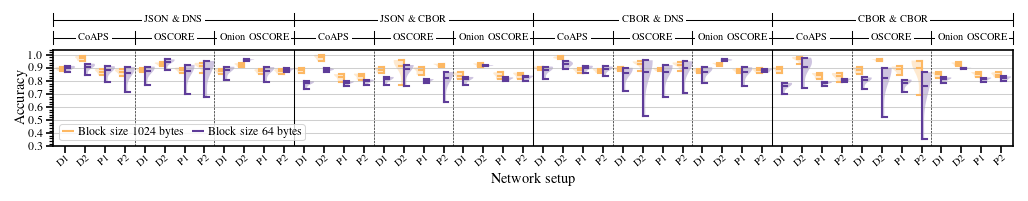

#### [$F_1$ score](plots/blockwise_rf_f1_score.pdf)

<Figure size 825.823x83.6699 with 0 Axes>

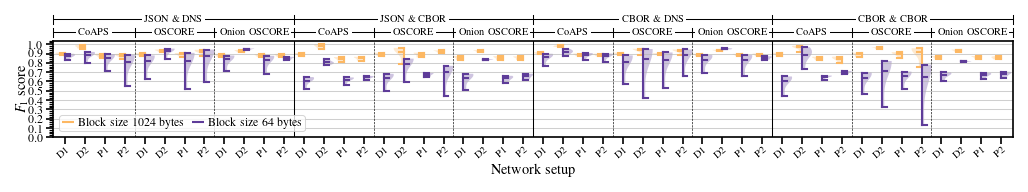

In [16]:
lf = polars.concat(
    map(
        lambda file: polars.scan_csv(
            file,
            separator=";",
            schema_overrides=SCHEMA_OVERRIDES,
        ),
        [
            INPUT_PATH / f"{scenario}.cross_val.csv"
            for scenario in list_scenarios(
                filter_protocol=["coaps", "oscore-base", "oscore"],
                filter_link_layer=[""],
                filter_randiv_pad=True,
            )
        ]
    )
).filter(
    polars.col("classifier") == CLASSIFIER
).with_columns(
    *[
        polars.col(col)
            .str.strip_chars_start("[")
            .str.strip_chars_end("]")
            .str.split(",")
            .list.eval(polars.element().str.strip_chars(" "))
            .cast(polars.List(polars.Float64))
        for col in list(METRICS_READABLE)
    ]
).with_columns(
    protocol_order=polars.col("protocol").map_elements(
        lambda prot: ["coaps", "oscore-base", "oscore"].index(prot),
        return_dtype=polars.Int8,
    ),
    data_format_order=polars.col("data_format").map_elements(
        lambda fmt: ["json", "cbor"].index(fmt),
        return_dtype=polars.Int8,
    ),
    dns_format_order=polars.col("dns_format").map_elements(
        lambda fmt: ["dns_message", "dns_cbor"].index(fmt),
        return_dtype=polars.Int8,
    ),
).sort(
    ["data_format_order", "dns_format_order", "protocol_order", "link_layer", "network_setup"]
)

lfs = {
    k: lf.filter(polars.col("blocksize") == k).with_row_index(offset=1)
    for k in [64, 1024]
}

# check if x-axis labels are the same
assert lfs[1024].select(
    ["protocol", "data_format", "dns_format", "link_layer", "network_setup"]
).collect().to_dict(as_series=False) == lfs[64].select(
    ["protocol", "data_format", "dns_format", "link_layer", "network_setup"]
).collect().to_dict(as_series=False)
for metric in METRICS_READABLE:
    matplotlib.pyplot.gcf()
    fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
    ax = matplotlib.pyplot.gca()
    violin_parts = {}
    blk_order = list(reversed(sorted(lfs)))
    for i, blk in enumerate(blk_order):
        metrics = lfs[blk].select([metric]).with_columns(
            polars.col(metric).list.to_struct(
                fields=[f"{metric}_fold{i}" for i in range(5)],
            )
        ).unnest(metric).collect().to_numpy().tolist()
        violin_parts[blk] = ax.violinplot(
            metrics,
            showmeans=True,
            widths=1,
            side="low" if blk == 1024 else "high",
        )

        ax.set_ylabel(f"{METRICS_READABLE[metric]}")
        ymin = 0.3 if metric == "accuracy" else 0.0
        ax.set_ylim(ymin, 1.00)
        ax.set_yticks(numpy.arange(ymin, 1.1, 0.1))
        ax.set_yticks(numpy.arange(ymin, 1.05, 0.02), minor=True)
    ax.grid(axis="y")
    ax.set_xlim(
        lfs[1024].collect()["index"].min() - 0.6,
        lfs[1024].collect()["index"].max() + 0.6,
    )
    mark_groups(ax, lfs[1024])
    ax.set_xlabel("Network setup", labelpad=2.0)
    ax.legend(
        [violin_parts[blk]["cbars"] for blk in blk_order],
        [f"Block size {blk} bytes" for blk in blk_order],
        ncol=2,
        loc="lower left",
    )
    filename = EVALUATION_PATH / "plots" / f"blockwise_{CLASSIFIER}_{metric}.pdf"
    matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
    display(Markdown(f"#### [{METRICS_READABLE[metric]}]({filename.relative_to(EVALUATION_PATH)})"))
    matplotlib.pyplot.show()

### Link-layer

Here we generate the plot we show in Section 6, Figure 14.

#### [Accuracy](plots/link_layer_1024_64_rf_accuracy.pdf)

<Figure size 825.823x83.6699 with 0 Axes>

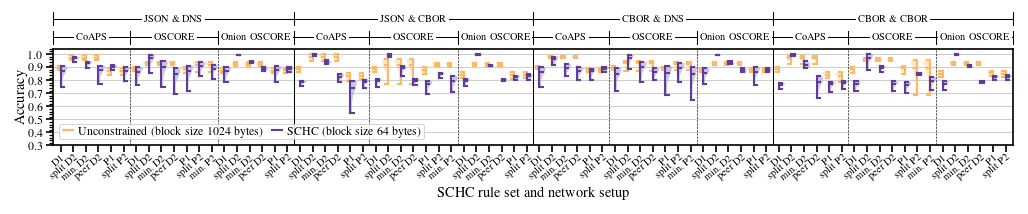

#### [$F_1$ score](plots/link_layer_1024_64_rf_f1_score.pdf)

<Figure size 825.823x83.6699 with 0 Axes>

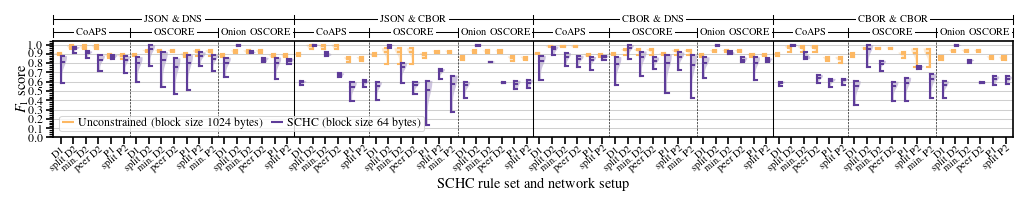

In [17]:
L2_READABLE = {
    "eth": "Unconstrained (block size 1024 bytes)",
    "schc": "SCHC (block size 64 bytes)",
}

lf = polars.concat(
    map(
        lambda file: polars.scan_csv(
            file,
            separator=";",
            schema_overrides=SCHEMA_OVERRIDES,
        ),
        [
            INPUT_PATH / f"{scenario}.cross_val.csv"
            for scenario in list_scenarios(
                filter_protocol=["coaps", "oscore-base", "oscore"],
                filter_randiv_pad=True,
            )
            if (
                ("_b64" in scenario and "-schc" in scenario)
                or ("_b64" not in scenario and "-schc" not in scenario)
            )
        ]
    )
).filter(
    polars.col("classifier") == CLASSIFIER
).with_columns(
    *[
        polars.col(col)
            .str.strip_chars_start("[")
            .str.strip_chars_end("]")
            .str.split(",")
            .list.eval(polars.element().str.strip_chars(" "))
            .cast(polars.List(polars.Float64))
        for col in list(METRICS_READABLE)
    ]
).with_columns(
    protocol_order=polars.col("protocol").map_elements(
        lambda prot: ["coaps", "oscore-base", "oscore"].index(prot),
        return_dtype=polars.Int8,
    ),
    data_format_order=polars.col("data_format").map_elements(
        lambda fmt: ["json", "cbor"].index(fmt),
        return_dtype=polars.Int8,
    ),
    dns_format_order=polars.col("dns_format").map_elements(
        lambda fmt: ["dns_message", "dns_cbor"].index(fmt),
        return_dtype=polars.Int8,
    ),
)

new_rows = None

for prot, stp, l2_mode, dns, data in lf.select(
    "protocol", "network_setup", "link_layer_mode", "dns_format", "data_format"
).unique().filter(
    polars.col("link_layer_mode").is_not_null()
).collect().rows():
    values = lf.filter(
        (polars.col("link_layer") == "eth")
        & (polars.col("protocol") == prot)
        & (polars.col("network_setup") == stp)
        #& (polars.col("blocksize") == blk)
        & (polars.col("dns_format") == dns)
        & (polars.col("data_format") == data)
        & polars.col("link_layer_mode").is_null()
    ).collect()
    new_row = lf.filter(
        (polars.col("link_layer") == "eth")
        & (polars.col("protocol") == prot)
        & (polars.col("network_setup") == stp)
        #& (polars.col("blocksize") == blk)
        & (polars.col("dns_format") == dns)
        & (polars.col("data_format") == data)
    ).with_columns(
        [polars.lit(l2_mode).alias("link_layer_mode")] + [
            polars.lit(values[col].first(), dtype=values[col].dtype).alias(col)
            for col in values.columns
            if col != "link_layer_mode"
        ]
    )
    if new_rows is None:
        new_rows = new_row
    else:
        new_rows = polars.concat([new_rows, new_row])

lf = polars.concat([lf, new_rows]).sort(
    ["data_format_order", "dns_format_order", "protocol_order", "link_layer", "network_setup", "link_layer_mode"]
)

lfs = {
    k: lf.filter(
        (polars.col("link_layer") == k)
    ).with_row_index(offset=1)
    for k in ["eth", "schc"]
}

# check if x-axis labels are the same
assert lfs["eth"].select(
    ["protocol", "data_format", "dns_format", "link_layer_mode", "network_setup"]
).collect().to_dict(as_series=False) == lfs["schc"].select(
    ["protocol", "data_format", "dns_format", "link_layer_mode", "network_setup"]
).collect().to_dict(as_series=False)
for metric in METRICS_READABLE:
    matplotlib.pyplot.gcf()
    fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
    ax = matplotlib.pyplot.gca()
    violin_parts = {}
    l2_order = list(sorted(lfs))
    for i, l2 in enumerate(l2_order):
        metrics = lfs[l2].select([metric]).with_columns(
            polars.col(metric).list.to_struct(
                fields=[f"{metric}_fold{i}" for i in range(5)],
            )
        ).unnest(metric).collect().to_numpy().tolist()
        violin_parts[l2] = ax.violinplot(
            metrics,
            showmeans=True,
            widths=1,
            side="low" if l2 == "eth" else "high",
        )

        ax.set_ylabel(f"{METRICS_READABLE[metric]}")
        ymin = 0.3 if metric == "accuracy" else 0.0
        ax.set_ylim(ymin, 1.00)
        ax.set_yticks(numpy.arange(ymin, 1.1, 0.1))
        ax.set_yticks(numpy.arange(ymin, 1.05, 0.02), minor=True)
    ax.grid(axis="y")
    ax.set_xlim(
        lfs["schc"].collect()["index"].min() - 0.6,
        lfs["schc"].collect()["index"].max() + 0.6,
    )
    mark_groups(ax, lfs["schc"])
    ax.set_xlabel("SCHC rule set and network setup", labelpad=2.0)
    ax.legend(
        [violin_parts[l2]["cbars"] for l2 in l2_order],
        [f"{L2_READABLE[l2]}" for l2 in l2_order],
        ncol=2,
        loc="lower left",
    )
    filename = EVALUATION_PATH / "plots" / f"link_layer_1024_64_{CLASSIFIER}_{metric}.pdf"
    matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
    display(Markdown(f"#### [{METRICS_READABLE[metric]}]({filename.relative_to(EVALUATION_PATH)})"))
    matplotlib.pyplot.show()